In [12]:
import pandas as pd
df = pd.read_csv('restaurant_info.csv')
df

,restaurant_name,location,cuisines,approx_cost(for two people),online_delivery,book_table
0,jalsa,banashankari,"north indian, mughlai, chinese",800,Yes,Yes
1,spice elephant,banashankari,"chinese, north indian, thai",800,Yes,No
2,san churro cafe,BANASHANKARI,"Cafe, Mexican, Italian",800,Yes,No
3,ADDHURI UDUPI BHOJANA,BANASHANKARI,"south indian, north indian",300,No,No
4,Grand Village,basavanagudi,"North Indian, Rajasthani",600,No,No
...,...,...,...,...,...,...
53924,SHANKAR MAANES KITCHEN,Hsr,"south indian, biryani, north indian",500,Yes,No
53925,abhiruchi hotel,bannerghatta road,"Andhra, Biryani, North Indian, Chinese",550,Yes,No
53926,Amber Rush Restobar,Residency Road,"Continental, Chinese, Fast Food","1,000",No,Yes
53927,Gold Line Breadz,kammanahalli,"bakery, fast food, desserts",350,No,No


In [13]:
df.isnull()

,restaurant_name,location,cuisines,approx_cost(for two people),online_delivery,book_table
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
...,...,...,...,...,...,...
53924,False,False,False,False,False,False
53925,False,False,False,False,False,False
53926,False,False,False,False,False,False
53927,False,False,False,False,False,False


In [14]:
df.columns

Index(['restaurant_name', 'location', 'cuisines',
       'approx_cost(for two people)', 'online_delivery', 'book_table'],
      dtype='object')

In [15]:
dff = pd.read_csv('restaurant_ratings.csv')
dff

,restaurant_name,location,rating,votes,rating_text
0,jalsa,Banashankari,4.1/5,775.0,"[('Rated 4.0', 'RATED\n A beautiful place to ..."
1,Spice Elephant,Banashankari,4.1/5,787.0,"[('Rated 4.0', 'RATED\n Had been here for din..."
2,SAN CHURRO CAFE,BANASHANKARI,3.8/5,918.0,"[('Rated 3.0', ""RATED\n Ambience is not that ..."
3,ADDHURI UDUPI BHOJANA,BANASHANKARI,3.7/5,88.0,"[('Rated 4.0', ""RATED\n Great food and proper..."
4,GRAND VILLAGE,Basavanagudi,3.8/5,166.0,"[('Rated 4.0', 'RATED\n Very good restaurant ..."
...,...,...,...,...,...
53924,SHANKAR MAANES KITCHEN,hsr,3.8/5,33.0,"[('Rated 5.0', 'RATED\n VERY TASTY FOOD, I HA..."
53925,ABHIRUCHI HOTEL,bannerghatta road,3.3/5,455.0,"[('Rated 2.0', ""RATED\n Okay I would like to ..."
53926,amber rush restobar,RESIDENCY ROAD,4.1 /5,105.0,"[('Rated 3.0', ""RATED\n Been here for a lunch..."
53927,gold line breadz,kammanahalli,3.7/5,53.0,"[('Rated 4.0', 'RATED\n Good collection of pa..."


In [16]:
dff.columns

Index(['restaurant_name', 'location', 'rating', 'votes', 'rating_text'], dtype='object')

In [17]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity

# Rename for convenience




In [18]:
def normalize_text(s: pd.Series) -> pd.Series:
    """Lowercase, strip, normalize whitespace; keep NaN as NaN."""
    s = s.astype("string")
    s = s.str.strip().str.lower()
    s = s.str.replace(r"\s+", " ", regex=True)
    return s

def parse_cost_to_float(x):
    """Convert approx_cost(for two people) to float; returns np.nan if not parseable."""
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    if x == "" or x.lower() in {"nan", "none"}:
        return np.nan
    # remove currency symbols and non-numeric (keep digits, dots, commas)
    x = re.sub(r"[^0-9\.,]", "", x)
    x = x.replace(",", "")
    try:
        return float(x)
    except:
        return np.nan

def clean_yes_no(x):
    """Normalize yes/no/true/false/0/1 to 0/1; unknown -> np.nan."""
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s in {"yes", "y", "true", "t", "1"}:
        return 1
    if s in {"no", "n", "false", "f", "0"}:
        return 0
    return np.nan

def split_cuisines(x):
    """Split comma-separated cuisines into a cleaned list."""
    if pd.isna(x):
        return []
    parts = [p.strip().lower() for p in str(x).split(",")]
    parts = [re.sub(r"\s+", " ", p) for p in parts if p.strip() != ""]
    return parts

In [19]:
df.isnull()

,restaurant_name,location,cuisines,approx_cost(for two people),online_delivery,book_table
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
...,...,...,...,...,...,...
53924,False,False,False,False,False,False
53925,False,False,False,False,False,False
53926,False,False,False,False,False,False
53927,False,False,False,False,False,False


In [20]:
data = pd.merge(df,dff)
data

,restaurant_name,location,cuisines,approx_cost(for two people),online_delivery,book_table,rating,votes,rating_text
0,Domino'S Pizza,BANASHANKARI,"pizza, fast food",800,Yes,No,3.9/5,540.0,"[('Rated 3.0', ""RATED\n I visit regularly wit..."
1,onesta,banashankari,"Pizza, Cafe, Italian",600,Yes,Yes,4.6/5,NaN,"[('Rated 5.0', 'RATED\n I personally really l..."
2,freshmenu,BANASHANKARI,"HEALTHY FOOD, CHINESE, BIRYANI, NORTH INDIAN, ...",450,Yes,No,3.9/5,627.0,"[('Rated 5.0', 'RATED\n What: continental foo..."
3,Sugar Rush,Banashankari,"BAKERY, DESSERTS",300,No,No,3.8/5,39.0,"[('Rated 1.0', 'RATED\n Wanted to try cupcake..."
4,Vijayalakshmi,BASAVANAGUDI,SOUTH INDIAN,200,Yes,No,3.9/5,47.0,"[('Rated 4.0', 'RATED\n Nice restaurant for s..."
...,...,...,...,...,...,...,...,...,...
1335,infinitea tea room & tea store,CUNNINGHAM ROAD,"continental, cafe, desserts, salad, momos","1,000",Yes,Yes,4.3/5,860.0,"[('Rated 4.0', 'RATED\n To all those tea love..."
1336,wyt restropub,Mg Road,"NORTH INDIAN, CHINESE","1,000",No,No,2.7/5,402.0,"[('Rated 5.0', 'RATED\n Well had been visit t..."
1337,1Q1,INFANTRY ROAD,"ASIAN, JAPANESE, THAI, MALAYSIAN, VIETNAMESE, ...","2,500",No,Yes,4.3/5,597.0,"[('Rated 4.0', 'RATED\n Awesome place would r..."
1338,Gilly'S Restobar,KORAMANGALA 5TH BLOCK,"finger food, continental, north indian","1,000",No,Yes,4.5/5,3902.0,"[('Rated 4.0', 'RATED\n Sunday evening!! A wo..."


In [21]:
data.isnull().sum()

restaurant_name                  0
location                         4
cuisines                         4
approx_cost(for two people)     97
online_delivery                  0
book_table                       0
rating                         172
votes                          117
rating_text                      0
dtype: int64

In [22]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   restaurant_name              1340 non-null   object 
 1   location                     1336 non-null   object 
 2   cuisines                     1336 non-null   object 
 3   approx_cost(for two people)  1243 non-null   object 
 4   online_delivery              1340 non-null   object 
 5   book_table                   1340 non-null   object 
 6   rating                       1168 non-null   object 
 7   votes                        1223 non-null   float64
 8   rating_text                  1340 non-null   object 
dtypes: float64(1), object(8)
memory usage: 94.3+ KB


In [23]:
# Step 1: Force numeric conversion on the cost column
data['approx_cost(for two people)'] = pd.to_numeric(
    data['approx_cost(for two people)']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.strip(),
    errors='coerce'
)

# Step 2: Fill nulls created by coerce
data['approx_cost(for two people)'] = data['approx_cost(for two people)'].fillna(
    data['approx_cost(for two people)'].median()
)

# Step 3: Verify dtype is now float64
print(data['approx_cost(for two people)'].dtype)  # should print: float64


float64


In [24]:
# Explode cuisines if comma-separated
data['cuisines'] = data['cuisines'].astype(str).str.split(', ')
data_exploded = data.explode('cuisines')

# Now groupby will work
cuisine_avg_cost = (
    data_exploded.groupby('cuisines')['approx_cost(for two people)']
    .mean()
    .round(2)
    .reset_index()
    .sort_values('approx_cost(for two people)', ascending=False)
)

print(cuisine_avg_cost)


          cuisines  approx_cost(for two people)
211          Grill                      4000.00
38    FINGER FOOD                       3000.00
388         korean                      2500.00
248         Korean                      2500.00
253      MALAYSIAN                      2500.00
..             ...                          ...
49          JUICES                       166.67
86            Tea                        150.00
82    Street Food                        150.00
83             TEA                       150.00
288           PAAN                       100.00

[434 rows x 2 columns]


In [25]:
data.isnull().sum()

restaurant_name                  0
location                         4
cuisines                         0
approx_cost(for two people)      0
online_delivery                  0
book_table                       0
rating                         172
votes                          117
rating_text                      0
dtype: int64

In [26]:
data.head()

,restaurant_name,location,cuisines,approx_cost(for two people),online_delivery,book_table,rating,votes,rating_text
0,Domino'S Pizza,BANASHANKARI,"[pizza, fast food]",800.0,Yes,No,3.9/5,540.0,"[('Rated 3.0', ""RATED\n I visit regularly wit..."
1,onesta,banashankari,"[Pizza, Cafe, Italian ]",600.0,Yes,Yes,4.6/5,NaN,"[('Rated 5.0', 'RATED\n I personally really l..."
2,freshmenu,BANASHANKARI,"[HEALTHY FOOD, CHINESE, BIRYANI, NORTH INDIAN,...",450.0,Yes,No,3.9/5,627.0,"[('Rated 5.0', 'RATED\n What: continental foo..."
3,Sugar Rush,Banashankari,"[BAKERY, DESSERTS]",300.0,No,No,3.8/5,39.0,"[('Rated 1.0', 'RATED\n Wanted to try cupcake..."
4,Vijayalakshmi,BASAVANAGUDI,[SOUTH INDIAN],200.0,Yes,No,3.9/5,47.0,"[('Rated 4.0', 'RATED\n Nice restaurant for s..."


In [27]:
data.isnull().sum()

restaurant_name                  0
location                         4
cuisines                         0
approx_cost(for two people)      0
online_delivery                  0
book_table                       0
rating                         172
votes                          117
rating_text                      0
dtype: int64

In [28]:
# Fix slice reference (if not already done)
data = data.copy()

# Ensure correct dtypes
data['rating'] = pd.to_numeric(
    data['rating'].astype(str).str.extract(r'(\d+\.\d+)')[0],
    errors='coerce'
)
data['votes'] = pd.to_numeric(data['votes'], errors='coerce')

# Fill nulls
data['rating'] = data['rating'].fillna(data['rating'].median())
data['votes']  = data['votes'].fillna(data['votes'].median())

# Clean location
data['location'] = data['location'].str.strip().str.title()

# Groupby location
location_stats = (
    data.groupby('location')
    .agg(
        Avg_Rating=('rating', 'mean'),
        Avg_Votes=('votes', 'mean')
    )
    .round(2)
    .reset_index()
    .sort_values('Avg_Rating', ascending=False)
)

print(location_stats)


                 location  Avg_Rating  Avg_Votes
24          Infantry Road        4.21     737.55
42           Lavelle Road        4.13    1132.21
34  Koramangala 3Rd Block        4.10     399.25
36  Koramangala 5Th Block        4.04    1341.44
53         Residency Road        4.01     515.40
..                    ...         ...        ...
11            City Market        3.43      23.67
43            Magadi Road        3.30      47.00
56           Sanjay Nagar        3.20       4.00
69            Yeshwantpur        3.20      31.00
6            Bommanahalli        3.12      10.25

[70 rows x 3 columns]


In [29]:
data.isnull().sum()

restaurant_name                0
location                       4
cuisines                       0
approx_cost(for two people)    0
online_delivery                0
book_table                     0
rating                         0
votes                          0
rating_text                    0
dtype: int64

In [30]:
data.location

0                Banashankari
1                Banashankari
2                Banashankari
3                Banashankari
4                Basavanagudi
                ...          
1335          Cunningham Road
1336                  Mg Road
1337            Infantry Road
1338    Koramangala 5Th Block
1339    Koramangala 5Th Block
Name: location, Length: 1340, dtype: object

In [31]:
data = data.dropna(subset=['location'])

# Verify
print(data['location'].isnull().sum())  # should print: 0
print(data.shape)                        # check remaining row count


0
(1336, 9)


In [32]:
data.isnull().sum()

restaurant_name                0
location                       0
cuisines                       0
approx_cost(for two people)    0
online_delivery                0
book_table                     0
rating                         0
votes                          0
rating_text                    0
dtype: int64

In [33]:
data.head()

,restaurant_name,location,cuisines,approx_cost(for two people),online_delivery,book_table,rating,votes,rating_text
0,Domino'S Pizza,Banashankari,"[pizza, fast food]",800.0,Yes,No,3.9,540.0,"[('Rated 3.0', ""RATED\n I visit regularly wit..."
1,onesta,Banashankari,"[Pizza, Cafe, Italian ]",600.0,Yes,Yes,4.6,55.0,"[('Rated 5.0', 'RATED\n I personally really l..."
2,freshmenu,Banashankari,"[HEALTHY FOOD, CHINESE, BIRYANI, NORTH INDIAN,...",450.0,Yes,No,3.9,627.0,"[('Rated 5.0', 'RATED\n What: continental foo..."
3,Sugar Rush,Banashankari,"[BAKERY, DESSERTS]",300.0,No,No,3.8,39.0,"[('Rated 1.0', 'RATED\n Wanted to try cupcake..."
4,Vijayalakshmi,Basavanagudi,[SOUTH INDIAN],200.0,Yes,No,3.9,47.0,"[('Rated 4.0', 'RATED\n Nice restaurant for s..."


Top cuisines by SUPPLY (restaurant_count):


,cuisine,restaurant_count,votes_sum,avg_rating,median_rating,supply_share,demand_share,oversaturation_index,votes_per_restaurant
59,north indian,494,181679.0,3.695720,3.8,0.151534,0.115646,0.035888,367.771255
19,chinese,372,115223.0,3.672727,3.8,0.114110,0.073344,0.040766,309.739247
70,south indian,210,34111.0,3.639171,3.8,0.064417,0.021713,0.042704,162.433333
16,cafe,179,142230.0,3.923077,4.0,0.054908,0.090535,-0.035627,794.581006
24,fast food,176,29277.0,3.717553,3.8,0.053988,0.018636,0.035352,166.346591
21,continental,171,116082.0,3.976923,4.0,0.052454,0.073891,-0.021437,678.842105
22,desserts,170,45776.0,3.884746,3.8,0.052147,0.029138,0.023009,269.270588
12,biryani,154,19772.0,3.621118,3.7,0.047239,0.012586,0.034654,128.389610
10,beverages,114,30945.0,3.827642,3.8,0.034969,0.019698,0.015272,271.447368
35,italian,95,82101.0,3.914563,4.0,0.029141,0.052261,-0.023120,864.221053



Top cuisines by DEMAND proxy (votes_sum):


,cuisine,restaurant_count,votes_sum,avg_rating,median_rating,supply_share,demand_share,oversaturation_index,votes_per_restaurant
59,north indian,494,181679.0,3.695720,3.8,0.151534,0.115646,0.035888,367.771255
16,cafe,179,142230.0,3.923077,4.0,0.054908,0.090535,-0.035627,794.581006
21,continental,171,116082.0,3.976923,4.0,0.052454,0.073891,-0.021437,678.842105
19,chinese,372,115223.0,3.672727,3.8,0.114110,0.073344,0.040766,309.739247
1,american,51,103543.0,4.118519,4.1,0.015644,0.065909,-0.050265,2030.254902
14,burger,59,90062.0,4.050000,4.1,0.018098,0.057328,-0.039230,1526.474576
35,italian,95,82101.0,3.914563,4.0,0.029141,0.052261,-0.023120,864.221053
71,steak,16,55032.0,4.094118,4.0,0.004908,0.035030,-0.030122,3439.500000
63,pizza,55,54952.0,4.045000,4.2,0.016871,0.034979,-0.018108,999.127273
66,salad,36,47780.0,4.056410,4.1,0.011043,0.030414,-0.019371,1327.222222



Potentially OVER-SATURATED cuisines (high supply share vs demand share):


,cuisine,restaurant_count,votes_sum,oversaturation_index,votes_per_restaurant,avg_rating
70,south indian,210,34111.0,0.042704,162.433333,3.639171
19,chinese,372,115223.0,0.040766,309.739247,3.672727
59,north indian,494,181679.0,0.035888,367.771255,3.695720
24,fast food,176,29277.0,0.035352,166.346591,3.717553
12,biryani,154,19772.0,0.034654,128.389610,3.621118
22,desserts,170,45776.0,0.023009,269.270588,3.884746
6,bakery,69,7507.0,0.016387,108.797101,3.748611
10,beverages,114,30945.0,0.015272,271.447368,3.827642
72,street food,66,11439.0,0.012964,173.318182,3.689855
33,ice cream,56,8961.0,0.011474,160.017857,3.856140



Potentially UNDER-SUPPLIED cuisines (demand share > supply share):


,cuisine,restaurant_count,votes_sum,oversaturation_index,votes_per_restaurant,avg_rating
1,american,51,103543.0,-0.050265,2030.254902,4.118519
14,burger,59,90062.0,-0.039230,1526.474576,4.050000
16,cafe,179,142230.0,-0.035627,794.581006,3.923077
71,steak,16,55032.0,-0.030122,3439.500000,4.094118
35,italian,95,82101.0,-0.023120,864.221053,3.914563
21,continental,171,116082.0,-0.021437,678.842105,3.976923
66,salad,36,47780.0,-0.019371,1327.222222,4.056410
63,pizza,55,54952.0,-0.018108,999.127273,4.045000
23,european,22,35086.0,-0.015585,1594.818182,4.130435
25,finger food,39,40973.0,-0.014118,1050.589744,4.135714


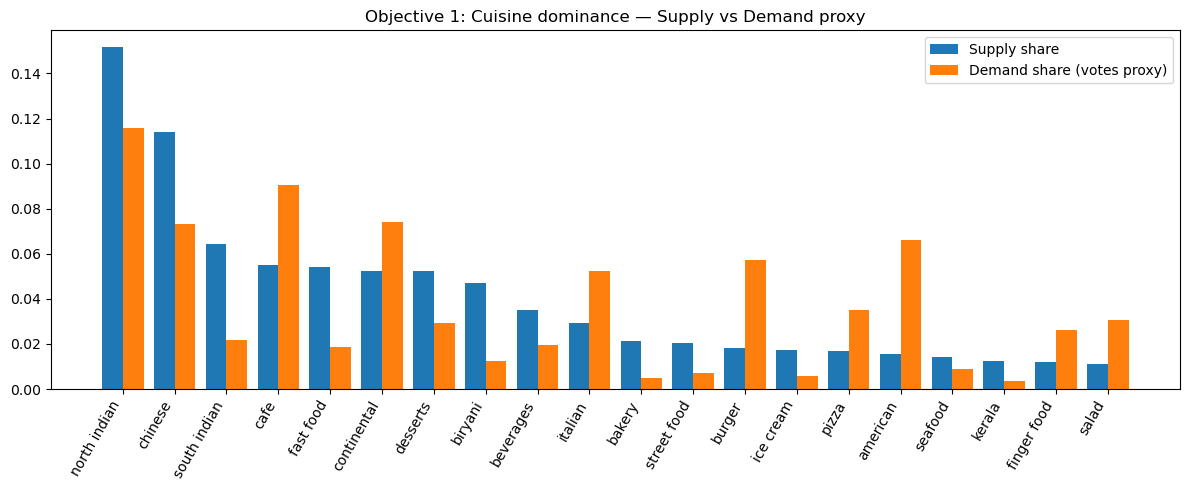

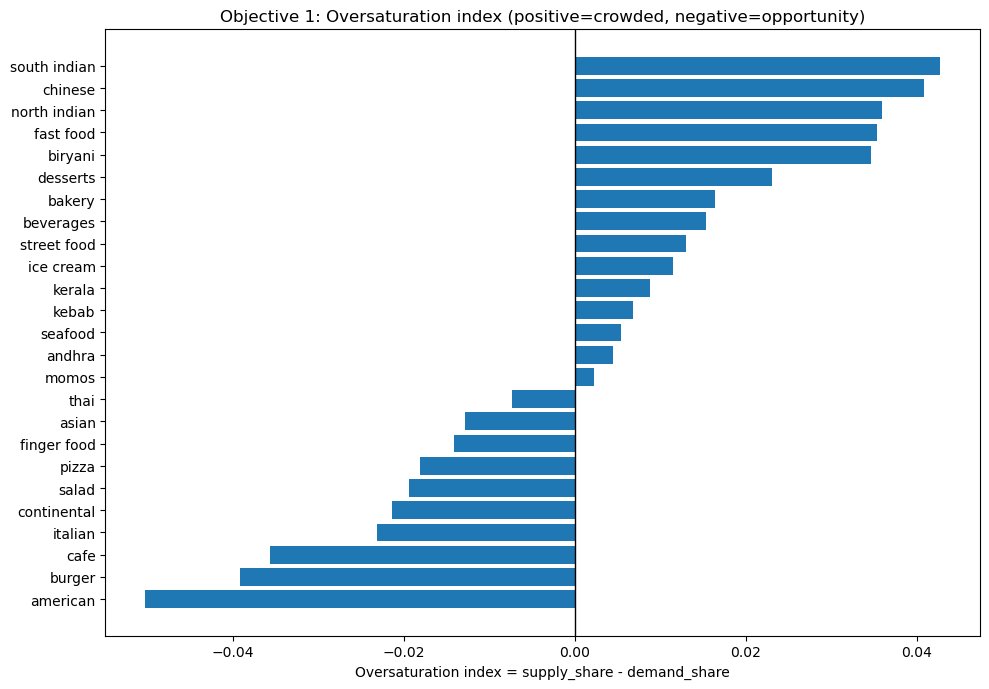


Best 'room to grow' cuisines with >= 10 restaurants in data:


,cuisine,restaurant_count,votes_sum,oversaturation_index,votes_per_restaurant,avg_rating
1,american,51,103543.0,-0.050265,2030.254902,4.118519
14,burger,59,90062.0,-0.039230,1526.474576,4.050000
16,cafe,179,142230.0,-0.035627,794.581006,3.923077
71,steak,16,55032.0,-0.030122,3439.500000,4.094118
35,italian,95,82101.0,-0.023120,864.221053,3.914563
21,continental,171,116082.0,-0.021437,678.842105,3.976923
66,salad,36,47780.0,-0.019371,1327.222222,4.056410
63,pizza,55,54952.0,-0.018108,999.127273,4.045000
23,european,22,35086.0,-0.015585,1594.818182,4.130435
25,finger food,39,40973.0,-0.014118,1050.589744,4.135714


In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Objective 1 — The Cuisine Landscape
# Goal:
# 1) Which cuisines dominate by SUPPLY? (restaurant_count)
# 2) Which cuisines dominate by DEMAND proxy? (votes_sum)
# 3) Oversaturated vs under-supplied cuisines using an "oversaturation index"
#    oversaturation_index = supply_share - demand_share
#    > 0  => more supply than demand share (potentially crowded)
#    < 0  => less supply than demand share (potential opportunity)

# Assumes `data` already exists with at least:
# restaurant_name, location, cuisines (list), votes, rating

data = data.copy()

# --- Normalize cuisines to a clean list ---
data["cuisine_list"] = data["cuisines"].apply(
    lambda xs: [str(x).strip().lower() for x in xs]
)

# --- Explode cuisines (1 row per cuisine per restaurant) ---
cuisine_df = (
    data[["restaurant_name", "location", "cuisine_list", "votes", "rating"]]
    .explode("cuisine_list")
    .rename(columns={"cuisine_list": "cuisine"})
)

# Ensure numeric types
cuisine_df["votes"] = cuisine_df["votes"].astype(float)
cuisine_df["rating"] = cuisine_df["rating"].astype(float)

# --- Compute supply + demand proxy per cuisine ---
cuisine_stats = (
    cuisine_df.groupby("cuisine", as_index=False)
    .agg(
        restaurant_count=("restaurant_name", "nunique"),  # supply
        votes_sum=("votes", "sum"),                      # demand proxy
        avg_rating=("rating", "mean"),
        median_rating=("rating", "median"),
    )
)

# Shares
cuisine_stats["supply_share"] = (
    cuisine_stats["restaurant_count"] / cuisine_stats["restaurant_count"].sum()
)

total_votes = cuisine_stats["votes_sum"].sum()
cuisine_stats["demand_share"] = (
    cuisine_stats["votes_sum"] / total_votes if total_votes > 0 else 0.0
)

# Oversaturation index: supply vs demand
cuisine_stats["oversaturation_index"] = (
    cuisine_stats["supply_share"] - cuisine_stats["demand_share"]
)

# (Optional) A quick "demand per restaurant" intensity metric
cuisine_stats["votes_per_restaurant"] = (
    cuisine_stats["votes_sum"] / cuisine_stats["restaurant_count"].replace(0, np.nan)
)

# --- Outputs ---
print("Top cuisines by SUPPLY (restaurant_count):")
display(cuisine_stats.sort_values("restaurant_count", ascending=False).head(20))

print("\nTop cuisines by DEMAND proxy (votes_sum):")
display(cuisine_stats.sort_values("votes_sum", ascending=False).head(20))

print("\nPotentially OVER-SATURATED cuisines (high supply share vs demand share):")
display(
    cuisine_stats.sort_values("oversaturation_index", ascending=False)
    .head(15)[["cuisine","restaurant_count","votes_sum","oversaturation_index","votes_per_restaurant","avg_rating"]]
)

print("\nPotentially UNDER-SUPPLIED cuisines (demand share > supply share):")
display(
    cuisine_stats.sort_values("oversaturation_index", ascending=True)
    .head(15)[["cuisine","restaurant_count","votes_sum","oversaturation_index","votes_per_restaurant","avg_rating"]]
)

# --- Visualization: supply share vs demand share (top 20 by supply) ---
topN = 20
top = cuisine_stats.sort_values("restaurant_count", ascending=False).head(topN).copy()

x = np.arange(topN)
plt.figure(figsize=(12, 5))
plt.bar(x - 0.2, top["supply_share"], width=0.4, label="Supply share")
plt.bar(x + 0.2, top["demand_share"], width=0.4, label="Demand share (votes proxy)")
plt.xticks(x, top["cuisine"], rotation=60, ha="right")
plt.title("Objective 1: Cuisine dominance — Supply vs Demand proxy")
plt.legend()
plt.tight_layout()
plt.show()

# --- Visualization: oversaturation index for top cuisines ---
top2 = cuisine_stats.sort_values("restaurant_count", ascending=False).head(25).copy()
top2 = top2.sort_values("oversaturation_index")

plt.figure(figsize=(10, 7))
plt.barh(top2["cuisine"], top2["oversaturation_index"])
plt.axvline(0, color="black", linewidth=1)
plt.title("Objective 1: Oversaturation index (positive=crowded, negative=opportunity)")
plt.xlabel("Oversaturation index = supply_share - demand_share")
plt.tight_layout()
plt.show()

# --- Advice helper: show "room-to-grow" cuisines with a minimum base size ---
# This avoids tiny cuisines showing up as "opportunity" just due to noise.
min_restaurants = 10  # tune
room_to_grow = cuisine_stats[cuisine_stats["restaurant_count"] >= min_restaurants] \
    .sort_values("oversaturation_index", ascending=True) \
    .head(15)

print(f"\nBest 'room to grow' cuisines with >= {min_restaurants} restaurants in data:")
display(room_to_grow[["cuisine","restaurant_count","votes_sum","oversaturation_index","votes_per_restaurant","avg_rating"]])

## Objective 1 — The Cuisine Landscape (Supply vs Demand)
**What to measure (from the dataset):**
- **Supply dominance:** cuisines with the highest **restaurant_count** (most listings).
- **Demand dominance (proxy):** cuisines with the highest **votes_sum** (most customer engagement).
- **Oversaturation index:**  
  **oversaturation_index = supply_share − demand_share**
  - **> 0:** more supply than demand share → potentially **crowded/oversupplied**
  - **< 0:** more demand than supply share → potentially **room to grow**

**How to interpret:**
- If a cuisine is **high supply** but has **lower demand share**, it likely has intense competition and may require strong differentiation (unique menu, branding, experience).
- If a cuisine is **lower supply** but has **higher demand share**, it may indicate an underserved segment.
- Use **votes_per_restaurant** to estimate “demand intensity” per cuisine (higher = stronger pull per available restaurant).

**What this means for someone opening a new restaurant:**
- Avoid entering cuisines that are **oversupplied** unless you have a clear unique selling proposition.
- Target cuisines that are **under-supplied** *and* have a reasonable base of restaurants (to avoid tiny-sample noise).
- Pair cuisine opportunity with location hotspot insights (Objective 3) to choose the best neighborhood.

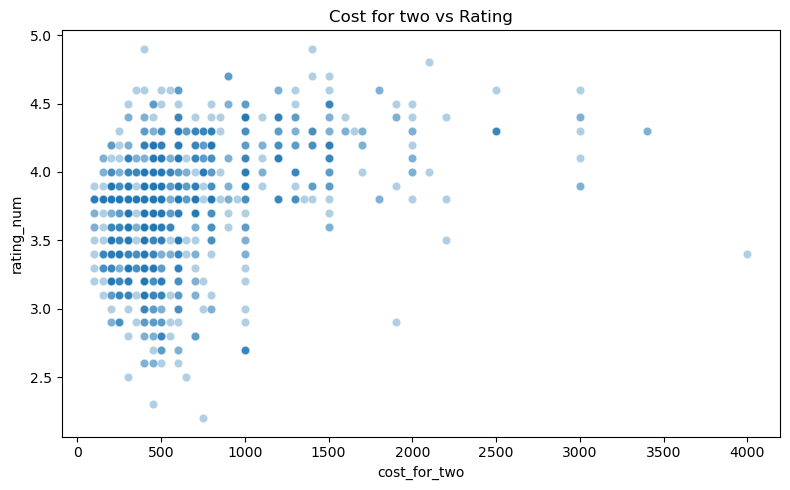

Correlation(cost, rating): 0.3685


C:\Users\Monish Tarun\AppData\Local\Temp\ipykernel_11472\17441760.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  d2.groupby("price_bucket", as_index=False)


,price_bucket,n,median_cost,median_rating,mean_rating,votes_sum
0,"(99.999, 300.0]",360,250.0,3.8,3.646917,16702.0
1,"(300.0, 400.0]",192,400.0,3.8,3.655500,21219.0
2,"(400.0, 500.0]",250,450.0,3.8,3.675769,50196.0
3,"(500.0, 800.0]",261,650.0,3.8,3.806522,130048.0
4,"(800.0, 2500.0]",203,1200.0,4.1,4.085253,252336.0


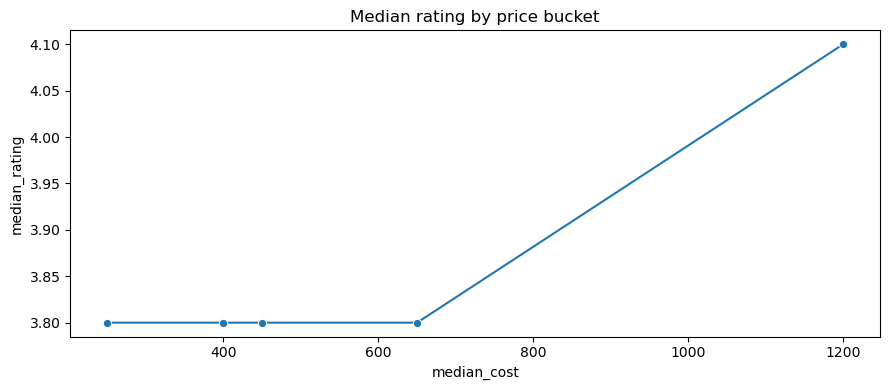

,price_bucket,n,median_cost,median_rating,mean_rating,votes_sum,value_score
4,"(800.0, 2500.0]",203,1200.0,4.1,4.085253,252336.0,50.997935
3,"(500.0, 800.0]",261,650.0,3.8,3.806522,130048.0,44.747533
2,"(400.0, 500.0]",250,450.0,3.8,3.675769,50196.0,41.130100
1,"(300.0, 400.0]",192,400.0,3.8,3.655500,21219.0,37.858258
0,"(99.999, 300.0]",360,250.0,3.8,3.646917,16702.0,36.948706


In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = data.copy()
data["rating_num"] = data["rating"].astype(float)
data["votes_num"] = data["votes"].astype(float)
data["cost_for_two"] = data["approx_cost(for two people)"].astype(float)

# Scatter
sample = data.sample(min(len(data), 4000), random_state=42)
plt.figure(figsize=(8,5))
sns.scatterplot(data=sample, x="cost_for_two", y="rating_num", alpha=0.35)
plt.title("Cost for two vs Rating")
plt.tight_layout()
plt.show()

# Correlation
corr = data[["cost_for_two","rating_num"]].corr().iloc[0,1]
print("Correlation(cost, rating):", round(corr, 4))

# Price buckets (quantiles)
cap = data["cost_for_two"].quantile(0.99)
d2 = data[data["cost_for_two"] <= cap].copy()
d2["price_bucket"] = pd.qcut(d2["cost_for_two"], q=5, duplicates="drop")

bucket_stats = (
    d2.groupby("price_bucket", as_index=False)
    .agg(
        n=("restaurant_name","nunique"),
        median_cost=("cost_for_two","median"),
        median_rating=("rating_num","median"),
        mean_rating=("rating_num","mean"),
        votes_sum=("votes_num","sum"),
    )
    .sort_values("median_cost")
)
display(bucket_stats)

plt.figure(figsize=(9,4))
sns.lineplot(data=bucket_stats, x="median_cost", y="median_rating", marker="o")
plt.title("Median rating by price bucket")
plt.tight_layout()
plt.show()

# “Sweet spot” value score
bucket_stats["value_score"] = bucket_stats["median_rating"] * np.log1p(bucket_stats["votes_sum"])
display(bucket_stats.sort_values("value_score", ascending=False))

## Objective 2 — The Price–Quality Paradox (Cost vs Satisfaction)
**What to measure:**
- Scatter of **cost_for_two vs rating**
- Correlation between **cost_for_two** and **rating**
- Ratings grouped by **price buckets** (quantiles)
- “Sweet spot” using a value metric like:  
  **value_score = median_rating × log1p(votes_sum)**

**How to interpret:**
- A weak correlation means **expensive does not guarantee better ratings**.
- If cheaper buckets have ratings comparable to higher buckets, budget places can **punch above their weight** on perceived value.
- The bucket with the best **value_score** is often the best “value-for-money” price zone.

**What this means for a restaurant owner:**
- Pricing above the sweet spot needs stronger justification (service, ambience, portion size, consistency).
- Pricing near the sweet spot tends to maximize “value perception,” improving satisfaction and engagement.
- If ratings do not rise with price, focus on quality consistency rather than increasing prices.

---

Top foodie hotspots:


,location,restaurants,avg_rating,median_rating,high_rated_count,votes_sum,foodie_score
36,Koramangala 5Th Block,89,4.044792,4.00,40,128778.0,111.989811
35,Koramangala 4Th Block,36,3.978947,4.10,16,34340.0,62.338832
63,Ulsoor,41,3.873913,3.80,15,8771.0,58.448885
23,Indiranagar,39,3.839024,3.90,11,33846.0,51.624728
61,St. Marks Road,17,4.010526,4.20,11,12595.0,51.493766
42,Lavelle Road,13,4.128571,4.30,9,15851.0,48.313908
47,Mg Road,36,3.720000,3.85,10,10815.0,47.888782
38,Koramangala 7Th Block,40,3.907500,3.90,9,13373.0,47.038568
7,Brigade Road,56,3.717241,3.80,9,17020.0,46.328410
53,Residency Road,20,4.010000,4.10,8,10308.0,45.290773


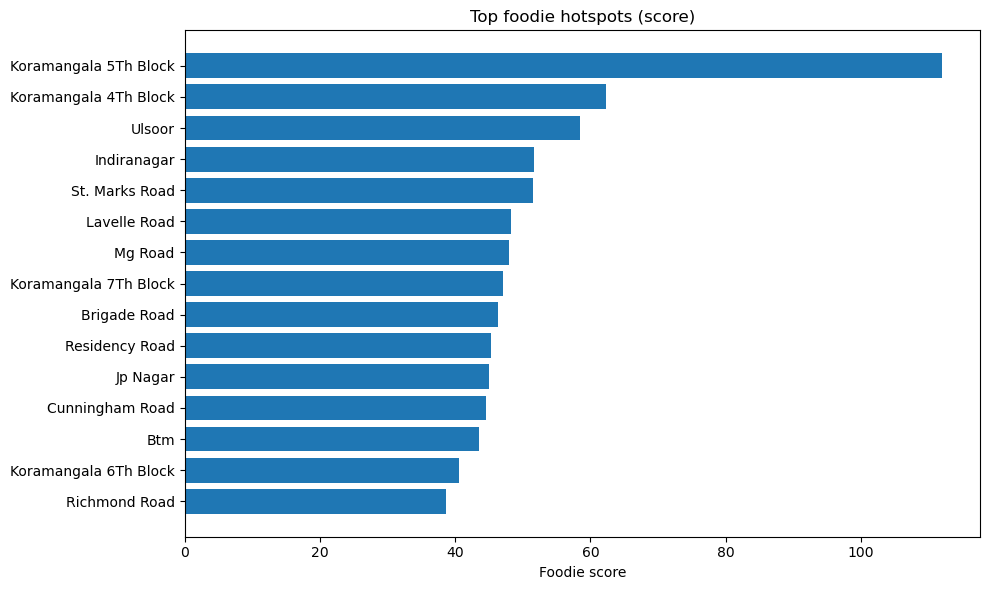

Food tour locations: ['Koramangala 5Th Block', 'Koramangala 4Th Block', 'Ulsoor']


,location,cuisine,restaurants,votes_sum,avg_rating
7,Koramangala 4Th Block,cafe,9,17884.0,4.044444
15,Koramangala 4Th Block,italian,6,13210.0,4.100000
23,Koramangala 4Th Block,pizza,3,10369.0,4.166667
6,Koramangala 4Th Block,burger,3,9487.0,4.333333
1,Koramangala 4Th Block,american,4,8747.0,4.275000
31,Koramangala 4Th Block,vietnamese,4,7220.0,4.400000
8,Koramangala 4Th Block,chinese,9,6345.0,3.933333
42,Koramangala 5Th Block,cafe,20,57495.0,4.150000
32,Koramangala 5Th Block,american,8,56033.0,4.310000
64,Koramangala 5Th Block,north indian,30,54337.0,4.163636


In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data = data.copy()
data["rating_num"] = data["rating"].astype(float)
data["votes_num"] = data["votes"].astype(float)

# Define “top-rated”
threshold = 4.2
data["high_rated"] = (data["rating_num"] >= threshold).astype(int)

loc_stats = (
    data.groupby("location", as_index=False)
    .agg(
        restaurants=("restaurant_name","nunique"),
        avg_rating=("rating_num","mean"),
        median_rating=("rating_num","median"),
        high_rated_count=("high_rated","sum"),
        votes_sum=("votes_num","sum"),
    )
)

# Filter noisy small locations
min_restaurants = 10
loc_stats_f = loc_stats[loc_stats["restaurants"] >= min_restaurants].copy()

# Hotspot score (tunable weights)
loc_stats_f["foodie_score"] = (
    2.0 * loc_stats_f["high_rated_count"]
    + 5.0 * loc_stats_f["avg_rating"]
    + np.log1p(loc_stats_f["votes_sum"])
)

loc_stats_f = loc_stats_f.sort_values("foodie_score", ascending=False)
print("Top foodie hotspots:")
display(loc_stats_f.head(20))

# Plot top 15
top_locs = loc_stats_f.head(15).sort_values("foodie_score", ascending=True)
plt.figure(figsize=(10,6))
plt.barh(top_locs["location"], top_locs["foodie_score"])
plt.title("Top foodie hotspots (score)")
plt.xlabel("Foodie score")
plt.tight_layout()
plt.show()

# “Data-driven food tour”: top 3 locations + top cuisines there by votes
data["cuisine_list"] = data["cuisines"].apply(lambda xs: [str(x).strip().lower() for x in xs])
cuisine_df = data[["restaurant_name","location","cuisine_list","votes_num","rating_num"]].explode("cuisine_list")
cuisine_df = cuisine_df.rename(columns={"cuisine_list":"cuisine"})

tour_locs = loc_stats_f.head(3)["location"].tolist()
tour = cuisine_df[cuisine_df["location"].isin(tour_locs)].copy()

tour_summary = (
    tour.groupby(["location","cuisine"], as_index=False)
    .agg(restaurants=("restaurant_name","nunique"),
         votes_sum=("votes_num","sum"),
         avg_rating=("rating_num","mean"))
    .sort_values(["location","votes_sum"], ascending=[True, False])
)

tour_top = tour_summary.groupby("location").head(7)
print("Food tour locations:", tour_locs)
display(tour_top)

Location summary (sorted by avg rating):


,location,n,mean_rating,median_rating,votes_sum,pct_top_rated
0,Infantry Road,6,4.21,4.30,8113.0,81.82
1,Lavelle Road,13,4.13,4.30,15851.0,71.43
2,Koramangala 3Rd Block,8,4.10,4.10,3194.0,87.50
3,Koramangala 5Th Block,89,4.04,4.00,128778.0,58.33
4,Residency Road,20,4.01,4.10,10308.0,65.00
...,...,...,...,...,...,...
65,City Market,3,3.43,3.50,71.0,0.00
66,Magadi Road,1,3.30,3.30,47.0,0.00
67,Sanjay Nagar,1,3.20,3.20,4.0,0.00
68,Yeshwantpur,2,3.20,3.20,62.0,0.00


C:\Users\Monish Tarun\AppData\Local\Temp\ipykernel_11472\167392591.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


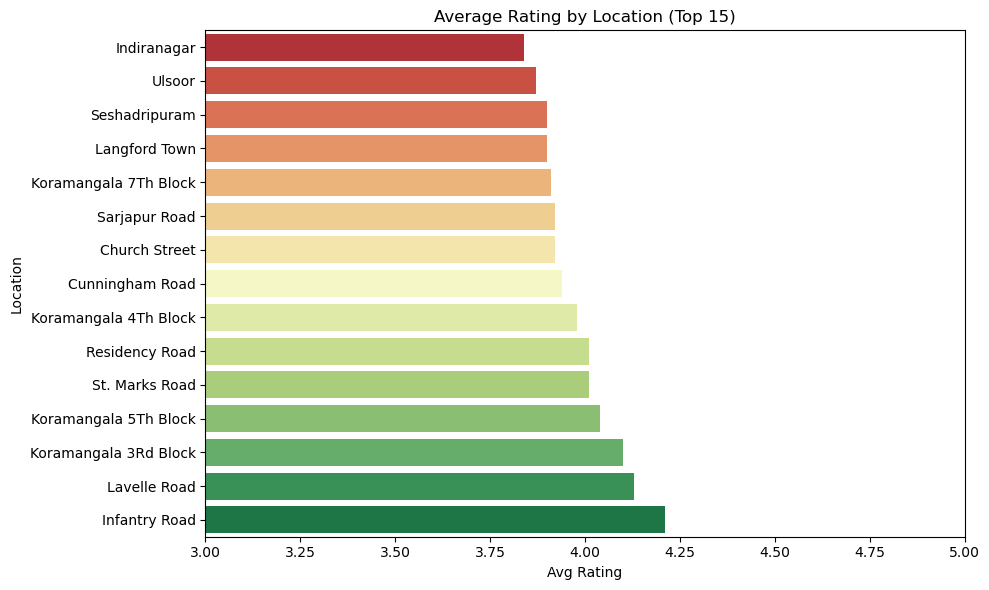

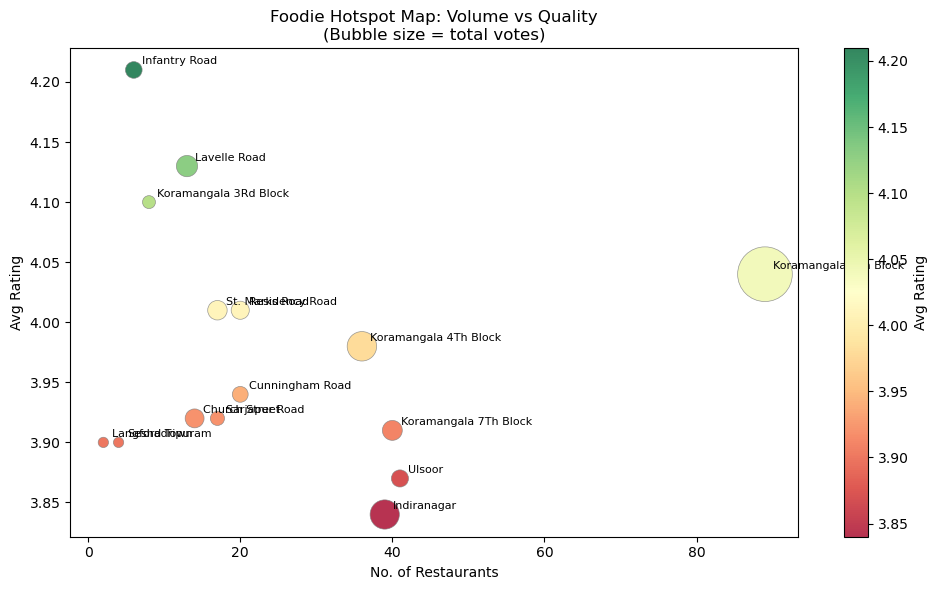

C:\Users\Monish Tarun\AppData\Local\Temp\ipykernel_11472\167392591.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


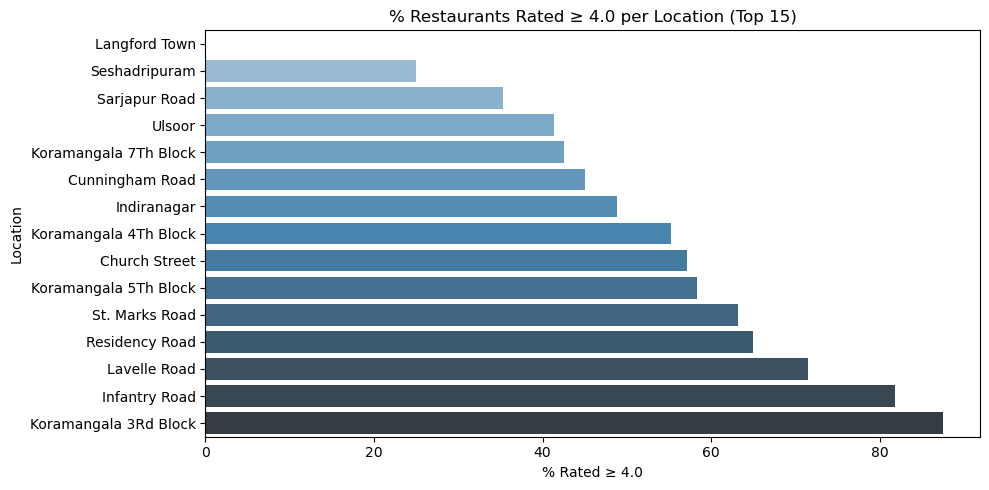

C:\Users\Monish Tarun\AppData\Local\Temp\ipykernel_11472\167392591.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


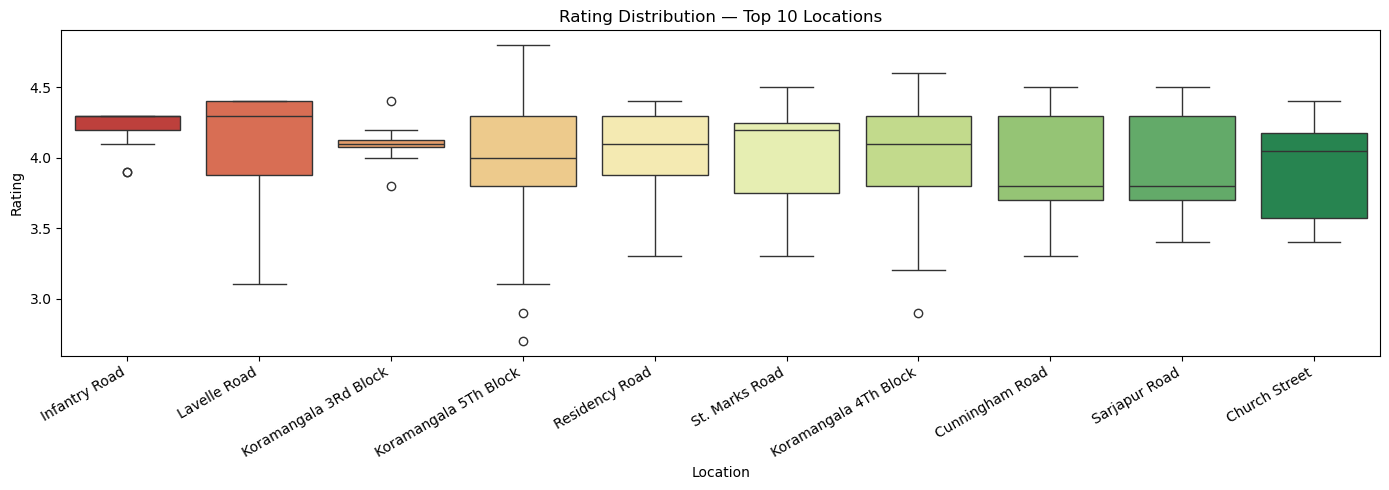

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = data.copy()
data["rating_num"] = pd.to_numeric(data["rating"], errors="coerce")
data["votes_num"] = pd.to_numeric(data["votes"], errors="coerce")

# ── Location-level summary ────────────────────────────────────────────────────
location_summary = (
    data.groupby("location", as_index=False)
    .agg(
        n              = ("restaurant_name", "nunique"),
        mean_rating    = ("rating_num", "mean"),
        median_rating  = ("rating_num", "median"),
        votes_sum      = ("votes_num", "sum"),
        pct_top_rated  = ("rating_num", lambda x: (x >= 4.0).mean() * 100)
    )
    .round(2)
    .sort_values("mean_rating", ascending=False)
    .reset_index(drop=True)
)

print("Location summary (sorted by avg rating):")
display(location_summary)

# ── Top 15 locations for cleaner plots ───────────────────────────────────────
top15 = location_summary.head(15).copy()

# ── Plot 1: Avg Rating per Location (horizontal bar) ─────────────────────────
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top15,
    x="mean_rating", y="location",
    palette="RdYlGn",
    order=top15.sort_values("mean_rating", ascending=True)["location"]
)
plt.title("Average Rating by Location (Top 15)")
plt.xlabel("Avg Rating")
plt.ylabel("Location")
plt.xlim(3.0, 5.0)
plt.tight_layout()
plt.show()

# ── Plot 2: Restaurant count vs Avg Rating (bubble = votes) ──────────────────
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    top15["n"],
    top15["mean_rating"],
    s=top15["votes_sum"] / top15["votes_sum"].max() * 1500 + 50,
    c=top15["mean_rating"],
    cmap="RdYlGn", alpha=0.8, edgecolors="grey", linewidths=0.5
)
for _, row in top15.iterrows():
    plt.annotate(
        row["location"],
        (row["n"], row["mean_rating"]),
        textcoords="offset points",
        xytext=(6, 4),
        fontsize=8
    )
plt.colorbar(scatter, label="Avg Rating")
plt.title("Foodie Hotspot Map: Volume vs Quality\n(Bubble size = total votes)")
plt.xlabel("No. of Restaurants")
plt.ylabel("Avg Rating")
plt.tight_layout()
plt.show()

# ── Plot 3: % Top-Rated restaurants (≥4.0) per Location ──────────────────────
plt.figure(figsize=(10, 5))
sns.barplot(
    data=top15,
    x="pct_top_rated", y="location",
    palette="Blues_d",
    order=top15.sort_values("pct_top_rated", ascending=True)["location"]
)
plt.title("% Restaurants Rated ≥ 4.0 per Location (Top 15)")
plt.xlabel("% Rated ≥ 4.0")
plt.ylabel("Location")
plt.tight_layout()
plt.show()

# ── Rating distribution across top 10 locations (boxplot) ────────────────────
top10_names = location_summary.head(10)["location"].tolist()
data_top10  = data[data["location"].isin(top10_names)].copy()

plt.figure(figsize=(14, 5))
sns.boxplot(
    data=data_top10,
    x="location", y="rating_num",
    order=top10_names,
    palette="RdYlGn"
)
plt.title("Rating Distribution — Top 10 Locations")
plt.xlabel("Location")
plt.ylabel("Rating")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


In [38]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier

data = data.copy()

# Basic columns
data["rating_num"] = data["rating"].astype(float)
data["votes_num"] = data["votes"].astype(float)
data["cost_for_two"] = data["approx_cost(for two people)"].astype(float)

yn = {"Yes": 1, "No": 0, "yes": 1, "no": 0}
data["online_delivery_flag"] = data["online_delivery"].map(yn).astype(int)
data["book_table_flag"] = data["book_table"].map(yn).astype(int)

data["cuisine_list"] = data["cuisines"].apply(lambda xs: [str(x).strip().lower() for x in xs])

# Target: high rating
threshold = 4.2
data["high_rating"] = (data["rating_num"] >= threshold).astype(int)

# Encode cuisines (multi-hot)
mlb = MultiLabelBinarizer()
cuisine_ohe = mlb.fit_transform(data["cuisine_list"])
cuisine_ohe = pd.DataFrame(cuisine_ohe, columns=[f"cuisine__{c}" for c in mlb.classes_], index=data.index)

# Encode location (one-hot)
loc_ohe = pd.get_dummies(data["location"].astype(str).str.strip().str.lower(), prefix="loc")

# Numeric features
X_num = data[["cost_for_two","votes_num","online_delivery_flag","book_table_flag"]].copy()

X = pd.concat([X_num, loc_ohe, cuisine_ohe], axis=1)
y = data["high_rating"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

clf = RandomForestClassifier(
    n_estimators=600,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample",
    min_samples_leaf=3
)
clf.fit(X_train, y_train)

pred = clf.predict(X_test)
print(classification_report(y_test, pred, digits=3))

# Feature importance
imp = (pd.DataFrame({"feature": X.columns, "importance": clf.feature_importances_})
       .sort_values("importance", ascending=False))
display(imp.head(30))

# Practical “what to fix first” buckets
print("\nTop operational drivers (if they appear high):")
display(imp[imp["feature"].isin(["cost_for_two","votes_num","online_delivery_flag","book_table_flag"])])

              precision    recall  f1-score   support

           0      0.942     0.883     0.912       222
           1      0.567     0.739     0.642        46

    accuracy                          0.858       268
   macro avg      0.754     0.811     0.777       268
weighted avg      0.878     0.858     0.865       268



,feature,importance
1,votes_num,0.307757
0,cost_for_two,0.179707
3,book_table_flag,0.101501
90,cuisine__cafe,0.026559
95,cuisine__continental,0.023392
144,cuisine__south indian,0.022217
93,cuisine__chinese,0.017618
137,cuisine__pizza,0.016593
78,cuisine__asian,0.015626
86,cuisine__biryani,0.015499



Top operational drivers (if they appear high):


,feature,importance
1,votes_num,0.307757
0,cost_for_two,0.179707
3,book_table_flag,0.101501
2,online_delivery_flag,0.011109


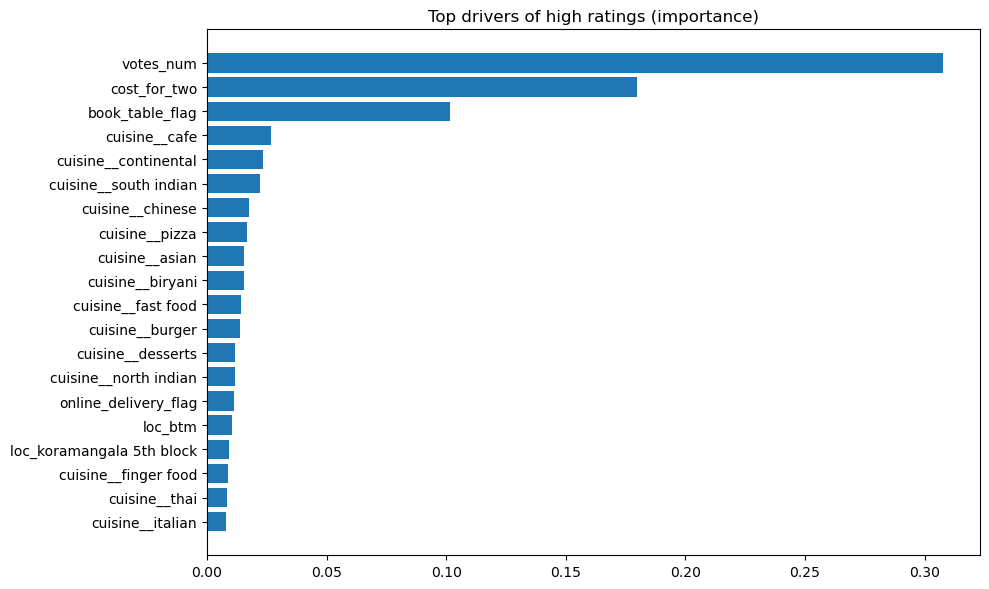

In [39]:
import matplotlib.pyplot as plt

top_imp = imp.head(20).sort_values("importance", ascending=True)
plt.figure(figsize=(10,6))
plt.barh(top_imp["feature"], top_imp["importance"])
plt.title("Top drivers of high ratings (importance)")
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd

data = data.copy()

data["rating_num"] = data["rating"].astype(float)
data["votes_num"] = data["votes"].astype(float)
data["cost_for_two"] = data["approx_cost(for two people)"].astype(float)
data["cuisine_list"] = data["cuisines"].apply(lambda xs: [str(x).strip().lower() for x in xs])

# Bayesian rating (confidence-adjusted)
global_mean = data["rating_num"].mean()
m = data["votes_num"].quantile(0.60)

def bayes_rating(r, v, C=global_mean, m=m):
    return (v/(v+m))*r + (m/(v+m))*C

data["bayes_rating"] = bayes_rating(data["rating_num"], data["votes_num"])

def jaccard(a, b):
    a, b = set(a), set(b)
    if not a and not b:
        return 0.0
    return len(a & b) / len(a | b)

def recommend(location, budget, preferred_cuisines, k=10, budget_tol=0.25, min_votes=0):
    loc = str(location).strip().lower()
    pref = [str(c).strip().lower() for c in preferred_cuisines]

    cand = data[data["location"].astype(str).str.strip().str.lower() == loc].copy()
    cand = cand[cand["votes_num"] >= min_votes]

    low, high = budget*(1-budget_tol), budget*(1+budget_tol)
    cand = cand[(cand["cost_for_two"] >= low) & (cand["cost_for_two"] <= high)]

    if cand.empty:
        return cand

    cand["cuisine_sim"] = cand["cuisine_list"].apply(lambda xs: jaccard(xs, pref))

    max_votes = data["votes_num"].max() if data["votes_num"].max() > 0 else 1.0
    cand["score"] = (
        0.55 * cand["cuisine_sim"]
        + 0.35 * (cand["bayes_rating"] / 5.0)
        + 0.10 * (np.log1p(cand["votes_num"]) / np.log1p(max_votes))
    )

    out = cand.sort_values("score", ascending=False).head(k)
    return out[[
        "restaurant_name", "location", "cuisines",
        "cost_for_two", "rating_num", "votes_num",
        "online_delivery", "book_table",
        "cuisine_sim", "bayes_rating", "score"
    ]]



In [41]:
# Pick a real location from your data
loc0 = data["location"].iloc[0]
display(recommend(loc0, budget=600, preferred_cuisines=["south indian"], k=10))
display(recommend(loc0, budget=600, preferred_cuisines=["chinese", "biryani"], k=10))

,restaurant_name,location,cuisines,cost_for_two,rating_num,votes_num,online_delivery,book_table,cuisine_sim,bayes_rating,score
62,Szechuan Dragon,Banashankari,"[chinese, thai, momos]",600.0,4.2,1647.0,Yes,No,0.0,4.180673,0.369829
2,freshmenu,Banashankari,"[HEALTHY FOOD, CHINESE, BIRYANI, NORTH INDIAN,...",450.0,3.9,627.0,Yes,No,0.0,3.885062,0.339083
1,onesta,Banashankari,"[Pizza, Cafe, Italian ]",600.0,4.6,55.0,Yes,Yes,0.0,4.113731,0.329904
516,STONED MONKEY,Banashankari,"[ desserts, ice cream]",500.0,4.3,55.0,Yes,No,0.0,3.987777,0.321087
479,CAFE VIVACITY,Banashankari,[ Cafe ],450.0,3.8,90.0,Yes,No,0.0,3.782523,0.311778
546,cafe vivacity,Banashankari,[CAFE],650.0,3.8,90.0,Yes,No,0.0,3.782523,0.311778
69,Sea Green Cafe,Banashankari,"[ CAFE, FAST FOOD, BEVERAGES ]",500.0,3.3,55.0,No,No,0.0,3.567930,0.291698


,restaurant_name,location,cuisines,cost_for_two,rating_num,votes_num,online_delivery,book_table,cuisine_sim,bayes_rating,score
62,Szechuan Dragon,Banashankari,"[chinese, thai, momos]",600.0,4.2,1647.0,Yes,No,0.25,4.180673,0.507329
2,freshmenu,Banashankari,"[HEALTHY FOOD, CHINESE, BIRYANI, NORTH INDIAN,...",450.0,3.9,627.0,Yes,No,0.25,3.885062,0.476583
1,onesta,Banashankari,"[Pizza, Cafe, Italian ]",600.0,4.6,55.0,Yes,Yes,0.00,4.113731,0.329904
516,STONED MONKEY,Banashankari,"[ desserts, ice cream]",500.0,4.3,55.0,Yes,No,0.00,3.987777,0.321087
479,CAFE VIVACITY,Banashankari,[ Cafe ],450.0,3.8,90.0,Yes,No,0.00,3.782523,0.311778
546,cafe vivacity,Banashankari,[CAFE],650.0,3.8,90.0,Yes,No,0.00,3.782523,0.311778
69,Sea Green Cafe,Banashankari,"[ CAFE, FAST FOOD, BEVERAGES ]",500.0,3.3,55.0,No,No,0.00,3.567930,0.291698


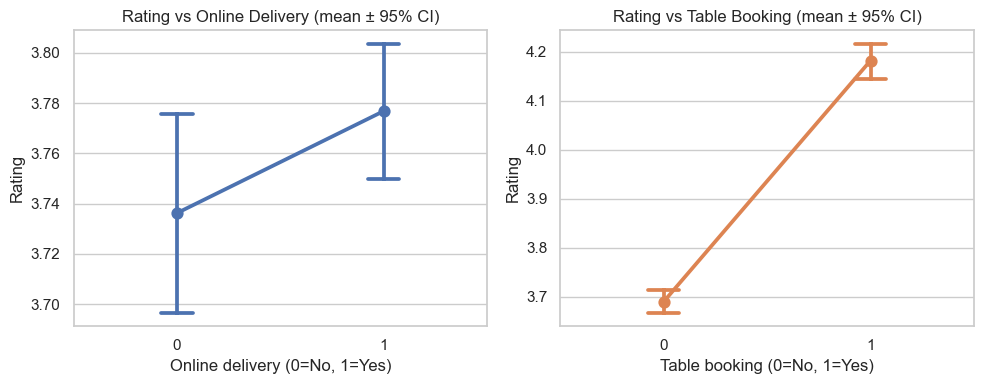

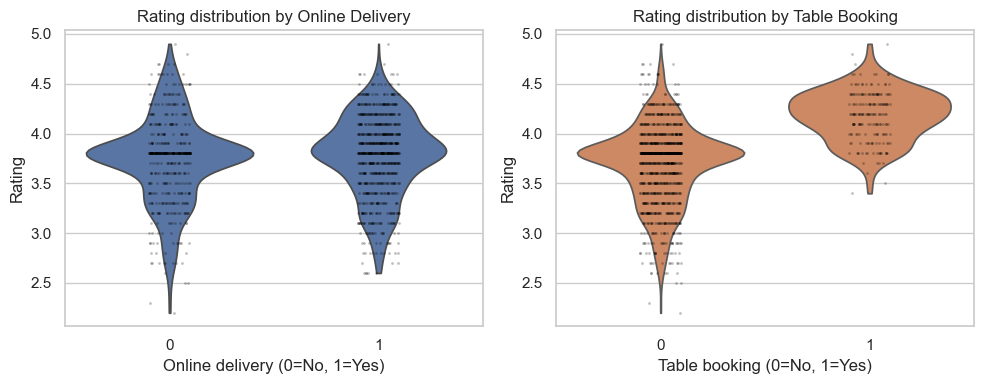

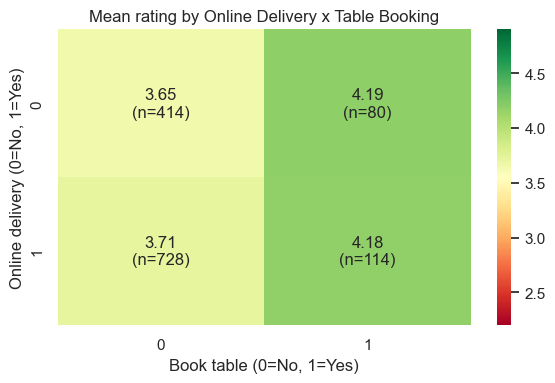

Objective 5: ROC AUC = 0.9077


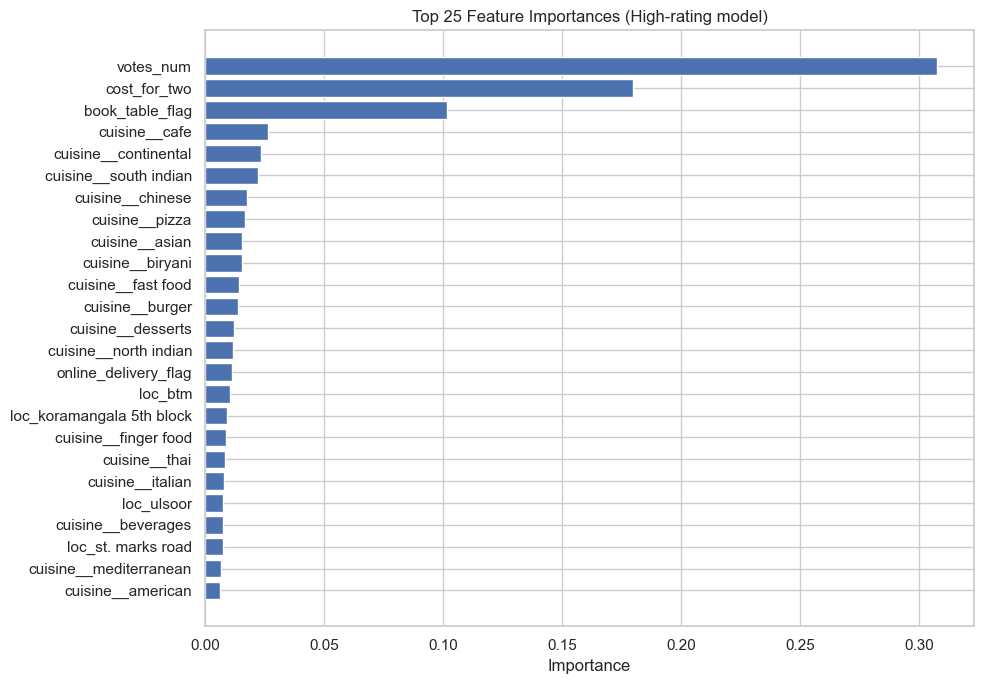

C:\Users\Monish Tarun\AppData\Local\Temp\ipykernel_11472\289246492.py:149: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=group_imp, x="importance", y="group", palette="viridis")


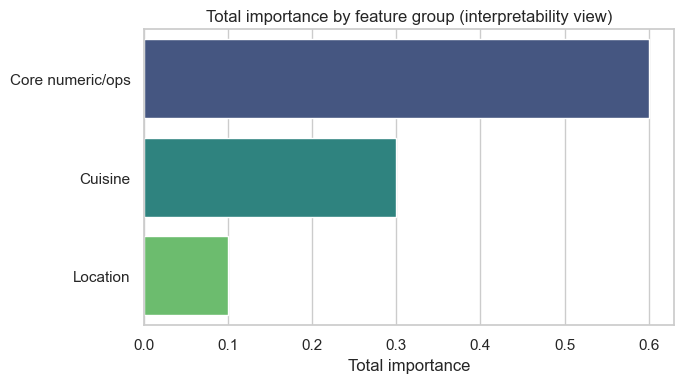

C:\Users\Monish Tarun\AppData\Local\Temp\ipykernel_11472\289246492.py:163: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cost_curve = tmp.groupby("cost_bin", as_index=False).agg(


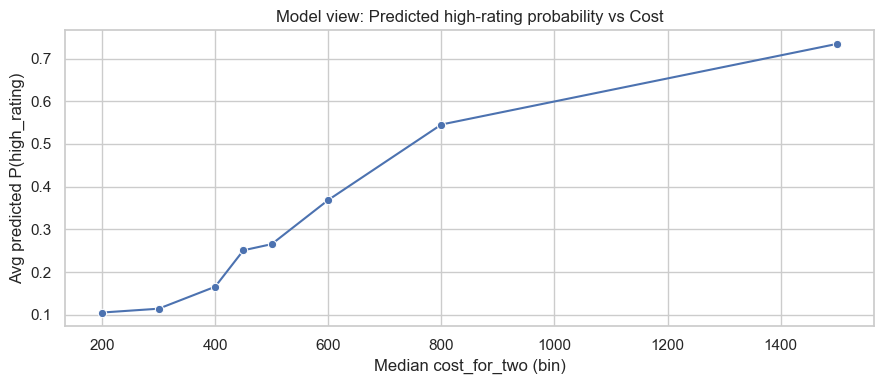

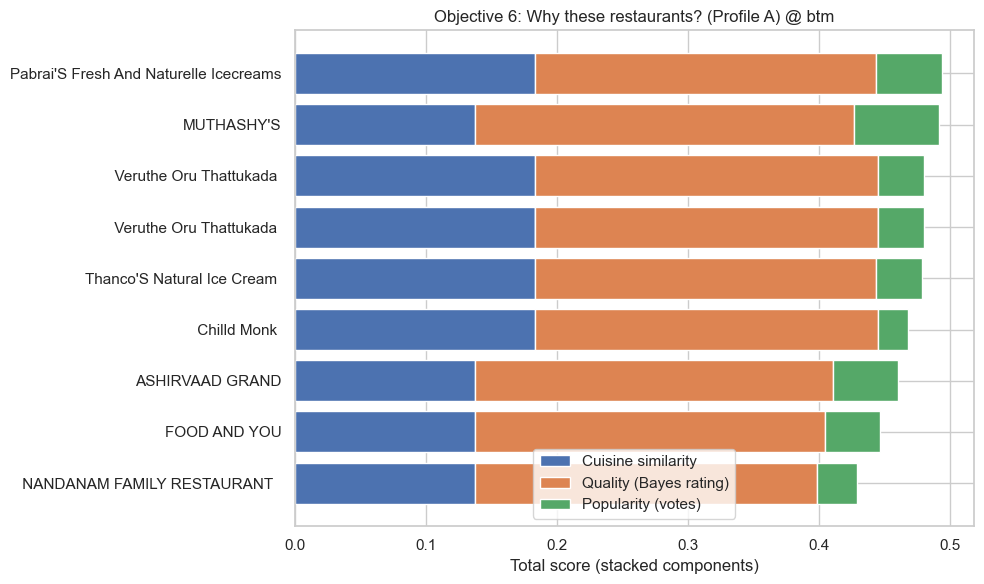

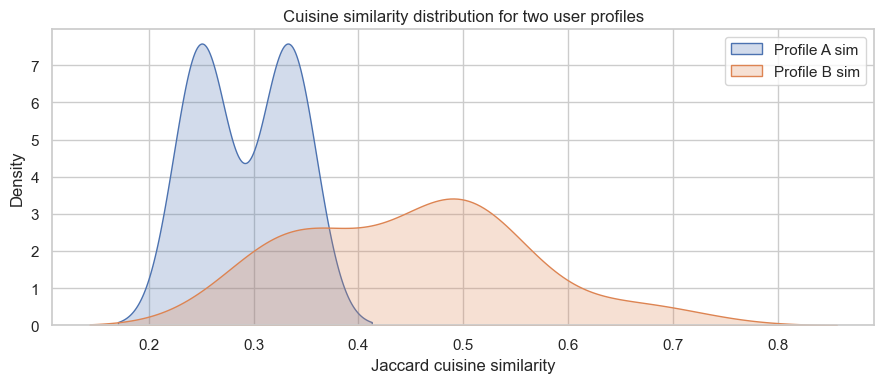

Objective 6: Diversity
Profile A unique cuisines in top-k: 8
Profile B unique cuisines in top-k: 11
Top-10 overlap count between profiles: 0
Overlap restaurants: set()


In [42]:
# Better graphs for Objectives 4, 5, 6
# Assumes your dataframe is named `data` and has:
# restaurant_name, location, cuisines(list), approx_cost(for two people), online_delivery, book_table, rating, votes

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

sns.set_theme(style="whitegrid")

# ---------- Common cleaning ----------
data = data.copy()
data["rating_num"] = data["rating"].astype(float)
data["votes_num"] = data["votes"].astype(float)
data["cost_for_two"] = data["approx_cost(for two people)"].astype(float)
data["location_norm"] = data["location"].astype(str).str.strip().str.lower()
data["cuisine_list"] = data["cuisines"].apply(lambda xs: [str(x).strip().lower() for x in xs])

yn = {"Yes": 1, "No": 0, "yes": 1, "no": 0}
data["online_delivery_flag"] = data["online_delivery"].map(yn).astype(int)
data["book_table_flag"] = data["book_table"].map(yn).astype(int)

# ======================================================================
# Objective 4 — Better Graphs
# ======================================================================

# 4A) Clean comparison: point plot with confidence intervals
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.pointplot(data=data, x="online_delivery_flag", y="rating_num", errorbar=("ci", 95), capsize=.15)
plt.title("Rating vs Online Delivery (mean ± 95% CI)")
plt.xlabel("Online delivery (0=No, 1=Yes)")
plt.ylabel("Rating")

plt.subplot(1,2,2)
sns.pointplot(data=data, x="book_table_flag", y="rating_num", errorbar=("ci", 95), capsize=.15, color="C1")
plt.title("Rating vs Table Booking (mean ± 95% CI)")
plt.xlabel("Table booking (0=No, 1=Yes)")
plt.ylabel("Rating")
plt.tight_layout()
plt.show()

# 4B) Distribution: violin + strip overlay (shows shape + individual density)
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.violinplot(data=data, x="online_delivery_flag", y="rating_num", inner=None, cut=0)
sns.stripplot(data=data.sample(min(len(data), 2500), random_state=42),
              x="online_delivery_flag", y="rating_num", color="black", alpha=0.25, size=2)
plt.title("Rating distribution by Online Delivery")
plt.xlabel("Online delivery (0=No, 1=Yes)")
plt.ylabel("Rating")

plt.subplot(1,2,2)
sns.violinplot(data=data, x="book_table_flag", y="rating_num", inner=None, cut=0, color="C1")
sns.stripplot(data=data.sample(min(len(data), 2500), random_state=42),
              x="book_table_flag", y="rating_num", color="black", alpha=0.25, size=2)
plt.title("Rating distribution by Table Booking")
plt.xlabel("Table booking (0=No, 1=Yes)")
plt.ylabel("Rating")
plt.tight_layout()
plt.show()

# 4C) Interaction heatmap (delivery x booking): mean rating + sample size annotation
pivot_mean = data.pivot_table(index="online_delivery_flag", columns="book_table_flag", values="rating_num", aggfunc="mean")
pivot_n = data.pivot_table(index="online_delivery_flag", columns="book_table_flag", values="rating_num", aggfunc="count")

annot = pivot_mean.copy().astype(str)
for i in pivot_mean.index:
    for j in pivot_mean.columns:
        annot.loc[i, j] = f"{pivot_mean.loc[i,j]:.2f}\n(n={int(pivot_n.loc[i,j])})"

plt.figure(figsize=(6,4))
sns.heatmap(pivot_mean, annot=annot, fmt="", cmap="RdYlGn", vmin=data["rating_num"].min(), vmax=data["rating_num"].max())
plt.title("Mean rating by Online Delivery x Table Booking")
plt.xlabel("Book table (0=No, 1=Yes)")
plt.ylabel("Online delivery (0=No, 1=Yes)")
plt.tight_layout()
plt.show()

# ======================================================================
# Objective 5 — Better Graphs (Model + Importance)
# ======================================================================

# Build a "high rating" classifier and plot:
# - top feature importances (clean categories)
# - ROC AUC diagnostic
threshold = 4.2
data["high_rating"] = (data["rating_num"] >= threshold).astype(int)

# Encode cuisines
mlb = MultiLabelBinarizer()
cuisine_ohe = mlb.fit_transform(data["cuisine_list"])
cuisine_ohe = pd.DataFrame(cuisine_ohe, columns=[f"cuisine__{c}" for c in mlb.classes_], index=data.index)

# Encode locations
loc_ohe = pd.get_dummies(data["location_norm"], prefix="loc")

# Numeric features
X_num = data[["cost_for_two","votes_num","online_delivery_flag","book_table_flag"]].copy()
X = pd.concat([X_num, loc_ohe, cuisine_ohe], axis=1)
y = data["high_rating"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

clf = RandomForestClassifier(
    n_estimators=600,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample",
    min_samples_leaf=3
)
clf.fit(X_train, y_train)

proba = clf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, proba)
print("Objective 5: ROC AUC =", round(auc, 4))

imp = pd.DataFrame({"feature": X.columns, "importance": clf.feature_importances_}).sort_values("importance", ascending=False)

# 5A) Top importance overall
top_imp = imp.head(25).sort_values("importance", ascending=True)
plt.figure(figsize=(10,7))
plt.barh(top_imp["feature"], top_imp["importance"])
plt.title("Top 25 Feature Importances (High-rating model)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# 5B) Aggregate importance by feature group (more interpretable)
def group_feature(f):
    if f in ["cost_for_two","votes_num","online_delivery_flag","book_table_flag"]:
        return "Core numeric/ops"
    if f.startswith("loc_"):
        return "Location"
    if f.startswith("cuisine__"):
        return "Cuisine"
    return "Other"

imp["group"] = imp["feature"].apply(group_feature)
group_imp = imp.groupby("group", as_index=False)["importance"].sum().sort_values("importance", ascending=False)

plt.figure(figsize=(7,4))
sns.barplot(data=group_imp, x="importance", y="group", palette="viridis")
plt.title("Total importance by feature group (interpretability view)")
plt.xlabel("Total importance")
plt.ylabel("")
plt.tight_layout()
plt.show()

# 5C) Partial dependence-like view (simple): rating vs cost buckets + predicted probability
# We'll bin cost and show average predicted high-rating probability in each bin.
tmp = data.copy()
tmp["pred_proba"] = clf.predict_proba(X)[:, 1]
tmp = tmp[tmp["cost_for_two"] <= tmp["cost_for_two"].quantile(0.99)].copy()
tmp["cost_bin"] = pd.qcut(tmp["cost_for_two"], q=8, duplicates="drop")

cost_curve = tmp.groupby("cost_bin", as_index=False).agg(
    median_cost=("cost_for_two","median"),
    mean_pred=("pred_proba","mean"),
    n=("pred_proba","size")
).sort_values("median_cost")

plt.figure(figsize=(9,4))
sns.lineplot(data=cost_curve, x="median_cost", y="mean_pred", marker="o")
plt.title("Model view: Predicted high-rating probability vs Cost")
plt.xlabel("Median cost_for_two (bin)")
plt.ylabel("Avg predicted P(high_rating)")
plt.tight_layout()
plt.show()

# ======================================================================
# Objective 6 — Better Graphs (Recommender Diagnostics)
# ======================================================================

# We'll visualize:
# - Score decomposition (cuisine similarity vs bayes rating vs popularity)
# - Diversity (how many unique cuisines appear in recommendations)
# - Comparison of recommendations for two different preference profiles

global_mean = data["rating_num"].mean()
m = data["votes_num"].quantile(0.60)

def bayes_rating(r, v, C=global_mean, m=m):
    return (v/(v+m))*r + (m/(v+m))*C

data["bayes_rating"] = bayes_rating(data["rating_num"], data["votes_num"])

def jaccard(a, b):
    a, b = set(a), set(b)
    if not a and not b:
        return 0.0
    return len(a & b) / len(a | b)

def recommend(location, budget, preferred_cuisines, k=10, budget_tol=0.25, min_votes=0):
    loc = str(location).strip().lower()
    pref = [str(c).strip().lower() for c in preferred_cuisines]

    cand = data[data["location_norm"] == loc].copy()
    cand = cand[cand["votes_num"] >= min_votes]

    low, high = budget*(1-budget_tol), budget*(1+budget_tol)
    cand = cand[(cand["cost_for_two"] >= low) & (cand["cost_for_two"] <= high)]
    if cand.empty:
        return cand

    cand["cuisine_sim"] = cand["cuisine_list"].apply(lambda xs: jaccard(xs, pref))

    max_votes = data["votes_num"].max() if data["votes_num"].max() > 0 else 1.0
    cand["sim_component"] = 0.55 * cand["cuisine_sim"]
    cand["quality_component"] = 0.35 * (cand["bayes_rating"] / 5.0)
    cand["pop_component"] = 0.10 * (np.log1p(cand["votes_num"]) / np.log1p(max_votes))

    cand["score"] = cand["sim_component"] + cand["quality_component"] + cand["pop_component"]

    out = cand.sort_values("score", ascending=False).head(k)
    return out

# Pick a valid location automatically (so code runs)
loc0 = data["location_norm"].value_counts().index[0]
budget0 = float(data["cost_for_two"].median())

rec_a = recommend(loc0, budget0, ["south indian", "desserts"], k=12)
rec_b = recommend(loc0, budget0, ["chinese", "biryani"], k=12)

# 6A) Score decomposition bar chart for one recommendation list
def plot_score_decomposition(recs, title):
    if recs is None or len(recs) == 0:
        print("No recs to plot for:", title)
        return
    r = recs.copy().head(10)
    r = r.sort_values("score", ascending=True)

    plt.figure(figsize=(10,6))
    plt.barh(r["restaurant_name"], r["sim_component"], label="Cuisine similarity")
    plt.barh(r["restaurant_name"], r["quality_component"], left=r["sim_component"], label="Quality (Bayes rating)")
    plt.barh(r["restaurant_name"], r["pop_component"], left=r["sim_component"]+r["quality_component"], label="Popularity (votes)")
    plt.title(title)
    plt.xlabel("Total score (stacked components)")
    plt.tight_layout()
    plt.legend()
    plt.show()

plot_score_decomposition(rec_a, f"Objective 6: Why these restaurants? (Profile A) @ {loc0}")

# 6B) Compare two preference profiles: similarity distribution
plt.figure(figsize=(9,4))
sns.kdeplot(rec_a["cuisine_sim"], fill=True, label="Profile A sim", common_norm=False)
sns.kdeplot(rec_b["cuisine_sim"], fill=True, label="Profile B sim", common_norm=False)
plt.title("Cuisine similarity distribution for two user profiles")
plt.xlabel("Jaccard cuisine similarity")
plt.legend()
plt.tight_layout()
plt.show()

# 6C) Diversity view: unique cuisines across recommendations (top-k)
def unique_cuisine_count(recs):
    s = set()
    for xs in recs["cuisine_list"]:
        for c in xs:
            s.add(c)
    return len(s)

if len(rec_a) > 0:
    print("Objective 6: Diversity")
    print("Profile A unique cuisines in top-k:", unique_cuisine_count(rec_a))
    print("Profile B unique cuisines in top-k:", unique_cuisine_count(rec_b))

# 6D) Simple “intelligence check”: do the top picks change when preferences change?
if len(rec_a) > 0 and len(rec_b) > 0:
    overlap = set(rec_a["restaurant_name"].head(10)) & set(rec_b["restaurant_name"].head(10))
    print("Top-10 overlap count between profiles:", len(overlap))
    print("Overlap restaurants:", overlap)



## Objective 4 — Feature Question (Online Delivery / Table Booking)

### 1) Point plots (mean ± 95% CI)
**What to look for**
- If the **mean rating** for `online_delivery_flag=1` is clearly higher than `0` *and* the confidence intervals barely overlap, then delivery is **associated with higher ratings**.
- Same logic for `book_table_flag`.

**Interpretation**
- **Higher mean with tight CI** → strong, consistent association.
- **Small mean difference + overlapping CI** → the feature likely has **little influence** on ratings.

**What you can conclude**
- If delivery/booking shows uplift: customers may reward convenience **or** better-managed restaurants adopt these features (correlation, not guaranteed causation).

---

### 2) Violin + strip plots (distribution shape)
**What to look for**
- Are the distributions shifted up (overall higher), or is it just a few extreme restaurants?
- Do “feature-enabled” restaurants have fewer low-rating outliers?

**Interpretation**
- **Whole distribution shifts upward** → feature group tends to be better overall.
- **Only tail changes** (few points) → difference may be driven by a small number of restaurants.

**What you can conclude**
- If the “Yes” group has a tighter, higher distribution, it signals **consistent operational quality**, not just a few popular places.

---

### 3) Interaction heatmap (Delivery × Booking)
**What to look for**
- The cell with the highest mean rating:
  - `Delivery=1, Booking=1` vs `1,0` vs `0,1` vs `0,0`
- The **n** (sample size) printed in each cell.

**Interpretation**
- If `1_1` (both enabled) is best and has a decent `n`, it suggests restaurants offering both services tend to be **higher-quality and/or better-run**.
- If a cell is very high but has low `n`, treat it as unreliable.

**What you can conclude**
- Use this to decide which feature is the bigger lever:
  - If delivery gives most uplift but booking doesn’t → prioritize delivery.
  - If booking uplift is higher → focus on dine-in experience and reservations.

---

## Objective 5 — Excellence Formula (Model + Interpretability)

### 1) Top 25 Feature Importance chart
**What to look for**
- Are the most important features mostly:
  - `loc_...` (location),
  - `cuisine__...` (cuisine),
  - or numeric/ops (`cost_for_two`, `votes_num`, delivery, booking)?

**Interpretation**
- **Location dominates** → ratings depend strongly on neighborhood dynamics (footfall, competition, customer profile).
- **Cuisine dominates** → category choice/menu positioning is a major driver.
- **Cost dominates** → value perception and pricing band matter.
- **Ops flags matter** → convenience/operations correlate with better ratings.

**What you can conclude (actionable)**
- If location dominates: open/market in hotspots (Objective 3).
- If cuisine dominates: shift cuisine mix toward high-demand under-supplied cuisines (Objective 1).
- If cost dominates: align to the sweet spot (Objective 2).
- If delivery/booking matters: enable and optimize it for quick wins.

---

### 2) Grouped importance bar chart (Location vs Cuisine vs Core numeric/ops)
**What to look for**
- The total importance contribution from each group.

**Interpretation**
- This is the cleanest “executive summary” of what drives ratings in your dataset.

**What you can conclude**
- The group with the highest total importance is your most strategic lever.

---

### 3) Predicted probability vs cost bins curve
**What to look for**
- The shape of the curve:
  - Rising → higher price bands tend to have higher predicted success.
  - Flat → price has little predictive value.
  - Peak in the middle → **sweet spot** (mid-price best).

**Interpretation**
- A **mid-price peak** supports “value-for-money” being the winning strategy.
- A steadily rising curve suggests a premium market where customers reward high-end experience.

**What you can conclude**
- Use this curve to justify your pricing strategy (especially for advising the struggling restaurant).

---

## Objective 6 — Recommendation System (Discovery Challenge)

### 1) Stacked score decomposition (Similarity + Quality + Popularity)
**What to look for**
- For each recommended restaurant, which component contributes most:
  - **Cuisine similarity**
  - **Bayesian quality** (confidence-adjusted rating)
  - **Popularity** (votes)

**Interpretation**
- If similarity dominates, recommendations are personalized.
- If quality dominates, recommendations skew toward “best overall.”
- If popularity dominates, it behaves like a “trending list.”

**What you can conclude**
- A good recommender usually has:
  - similarity as a major driver (personal relevance),
  - quality as a stabilizer (avoid bad picks),
  - popularity as a minor tie-breaker (avoid random low-signal picks).

---

### 2) Similarity KDE comparison (two user profiles)
**What to look for**
- Do the similarity distributions shift depending on user preferences?

**Interpretation**
- If Profile A and B look different, the system is responding to preferences.
- If they look identical, it’s probably acting like a generic top-rated list.

**What you can conclude**
- This plot is evidence that the recommender is doing “food similarity,” not just filtering.

---

### 3) Diversity metric (unique cuisines in top-k)
**What to look for**
- Number of unique cuisines appearing in recommendations.

**Interpretation**
- Very low diversity → repetitive list, possibly too narrow.
- Very high diversity → may be too broad and less personalized.

**What you can conclude**
- Diversity is a useful balance metric: personalized but not monotonous.

---

### 4) Top-10 overlap between profiles (“intelligence check”)
**What to look for**
- Overlap count and overlap list.

**Interpretation**
- High overlap → recommendations are mostly driven by location/ratings, not preferences.
- Low/moderate overlap → system adapts to the user’s cuisine taste.

**What you can conclude**
- This is a simple, strong argument in your report that the system is more than “sort by rating.”

---

---**Below are alternative approaches for Objective 4,5,6 **
---

C:\Users\Monish Tarun\AppData\Local\Temp\ipykernel_11472\2356748725.py:33: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  ax = sns.pointplot(


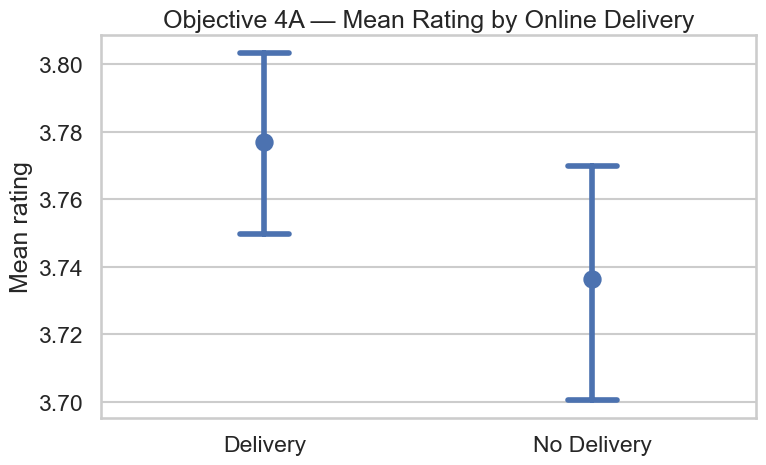

Insight 4A:
online_delivery_lbl
Delivery       3.777
No Delivery    3.736
Name: rating_num, dtype: float64


C:\Users\Monish Tarun\AppData\Local\Temp\ipykernel_11472\2356748725.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


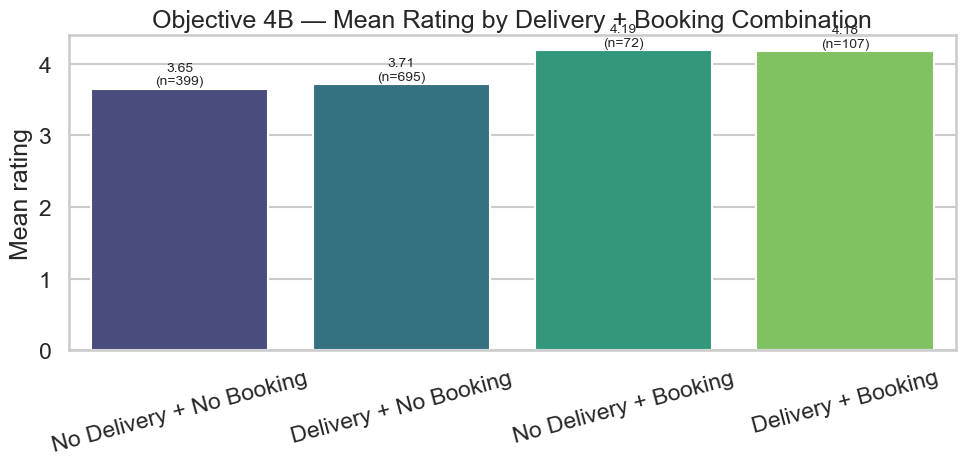

Insight 4B:
              feature_combo  mean_rating    n
3  No Delivery + No Booking     3.649034  399
1     Delivery + No Booking     3.713874  695
2     No Delivery + Booking     4.187500   72
0        Delivery + Booking     4.178947  107


C:\Users\Monish Tarun\AppData\Local\Temp\ipykernel_11472\2356748725.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


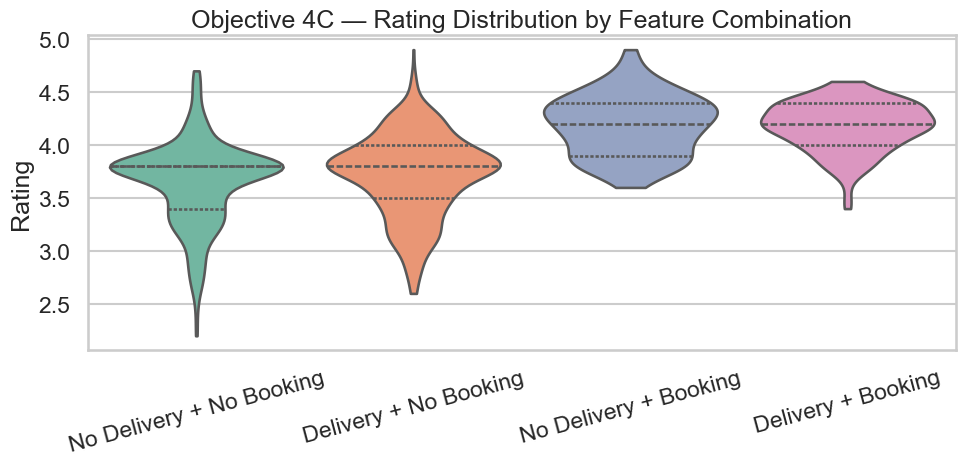

Interpretation:
- Point plot shows average effect.
- Bar chart shows which feature combination performs best.
- Violin plot shows whether the gain is consistent or driven by outliers.


In [43]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="talk")

# ---------------- Common cleaning ----------------
data = data.copy()
data["rating_num"] = pd.to_numeric(data["rating"], errors="coerce")
data["votes_num"] = pd.to_numeric(data["votes"], errors="coerce")

yn = {"Yes": 1, "No": 0, "yes": 1, "no": 0}
data["online_delivery_flag"] = data["online_delivery"].map(yn).astype(int)
data["book_table_flag"] = data["book_table"].map(yn).astype(int)

data = data.dropna(subset=["rating_num"])

# Friendly labels
data["online_delivery_lbl"] = data["online_delivery_flag"].map({0: "No Delivery", 1: "Delivery"})
data["book_table_lbl"] = data["book_table_flag"].map({0: "No Booking", 1: "Booking"})
data["feature_combo"] = data["online_delivery_lbl"] + " + " + data["book_table_lbl"]

combo_order = [
    "No Delivery + No Booking",
    "Delivery + No Booking",
    "No Delivery + Booking",
    "Delivery + Booking"
]

# ---------------- 4A: Mean rating with CI ----------------
plt.figure(figsize=(8, 5))
ax = sns.pointplot(
    data=data,
    x="online_delivery_lbl",
    y="rating_num",
    errorbar=("ci", 95),
    capsize=.15,
    join=False
)
plt.title("Objective 4A — Mean Rating by Online Delivery")
plt.xlabel("")
plt.ylabel("Mean rating")
plt.tight_layout()
plt.show()

delivery_means = data.groupby("online_delivery_lbl")["rating_num"].mean().round(3)
print("Insight 4A:")
print(delivery_means)

# ---------------- 4B: Interaction effect ----------------
interaction_summary = (
    data.groupby("feature_combo", as_index=False)
    .agg(
        mean_rating=("rating_num", "mean"),
        median_rating=("rating_num", "median"),
        n=("restaurant_name", "nunique"),
        votes_sum=("votes_num", "sum")
    )
)
interaction_summary["feature_combo"] = pd.Categorical(
    interaction_summary["feature_combo"],
    categories=combo_order,
    ordered=True
)
interaction_summary = interaction_summary.sort_values("feature_combo")

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=interaction_summary,
    x="feature_combo",
    y="mean_rating",
    palette="viridis"
)
for i, row in interaction_summary.reset_index(drop=True).iterrows():
    ax.text(i, row["mean_rating"] + 0.02, f'{row["mean_rating"]:.2f}\n(n={int(row["n"])})',
            ha="center", va="bottom", fontsize=10)
plt.title("Objective 4B — Mean Rating by Delivery + Booking Combination")
plt.xlabel("")
plt.ylabel("Mean rating")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print("Insight 4B:")
print(interaction_summary[["feature_combo", "mean_rating", "n"]])

# ---------------- 4C: Rating distribution ----------------
plt.figure(figsize=(10, 5))
sns.violinplot(
    data=data,
    x="feature_combo",
    y="rating_num",
    order=combo_order,
    inner="quartile",
    cut=0,
    palette="Set2"
)
plt.title("Objective 4C — Rating Distribution by Feature Combination")
plt.xlabel("")
plt.ylabel("Rating")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print("Interpretation:")
print("- Point plot shows average effect.")
print("- Bar chart shows which feature combination performs best.")
print("- Violin plot shows whether the gain is consistent or driven by outliers.")


C:\Users\Monish Tarun\AppData\Local\Temp\ipykernel_11472\3992396281.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


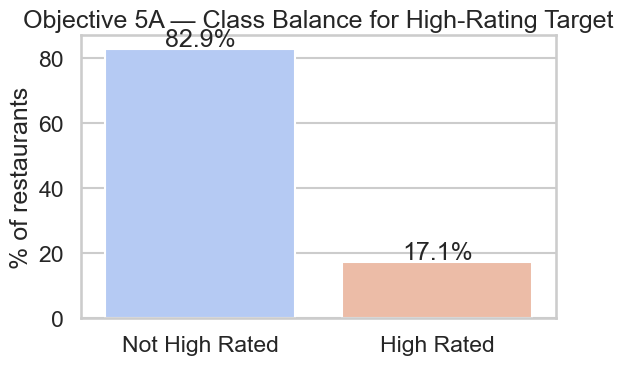

Objective 5: ROC AUC = 0.907


C:\Users\Monish Tarun\AppData\Local\Temp\ipykernel_11472\3992396281.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


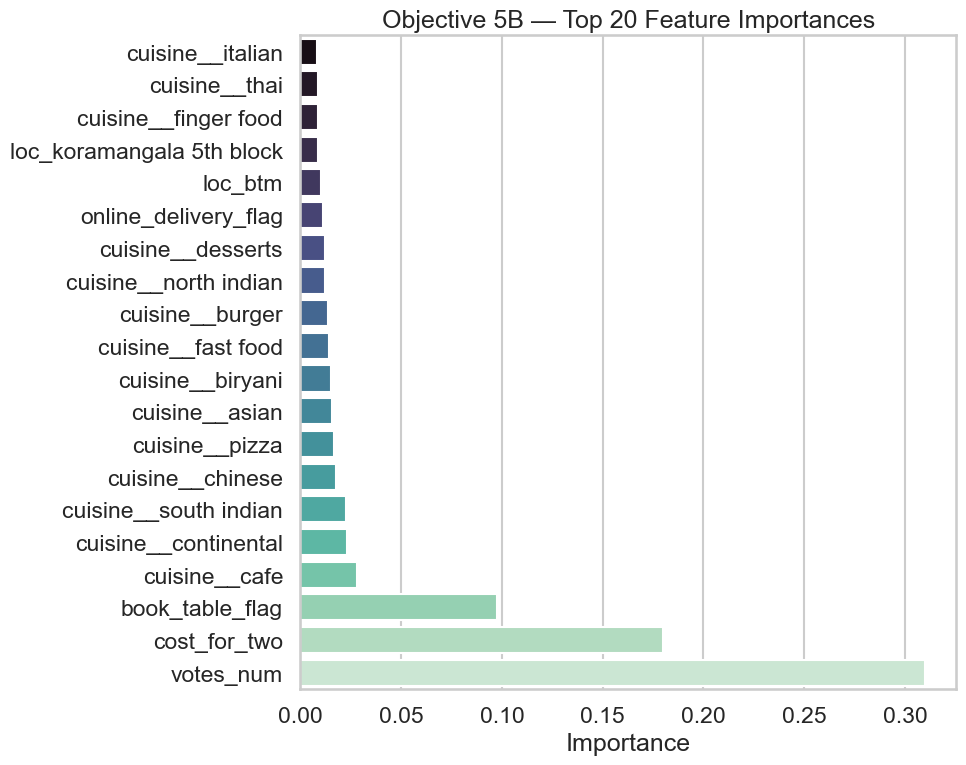

C:\Users\Monish Tarun\AppData\Local\Temp\ipykernel_11472\3992396281.py:118: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=group_imp, x="importance", y="group", palette="viridis")


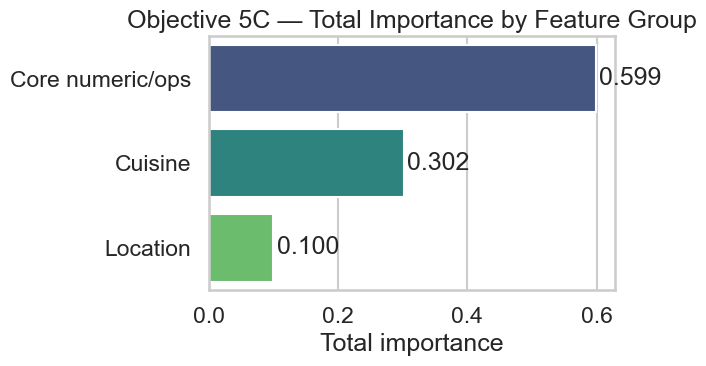

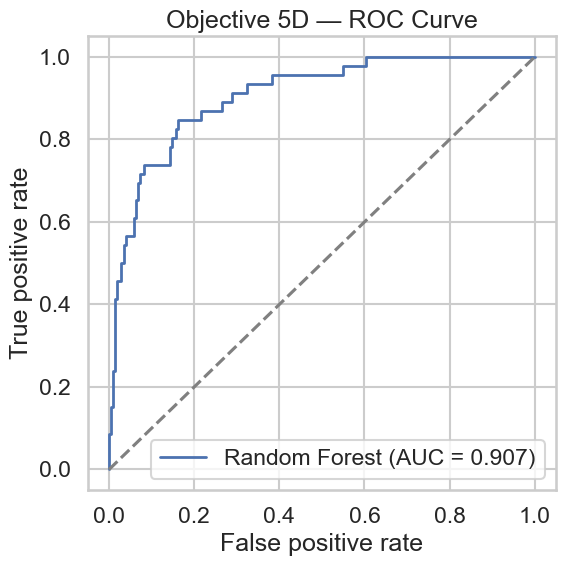

C:\Users\Monish Tarun\AppData\Local\Temp\ipykernel_11472\3992396281.py:147: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp.groupby("cost_bin", as_index=False)


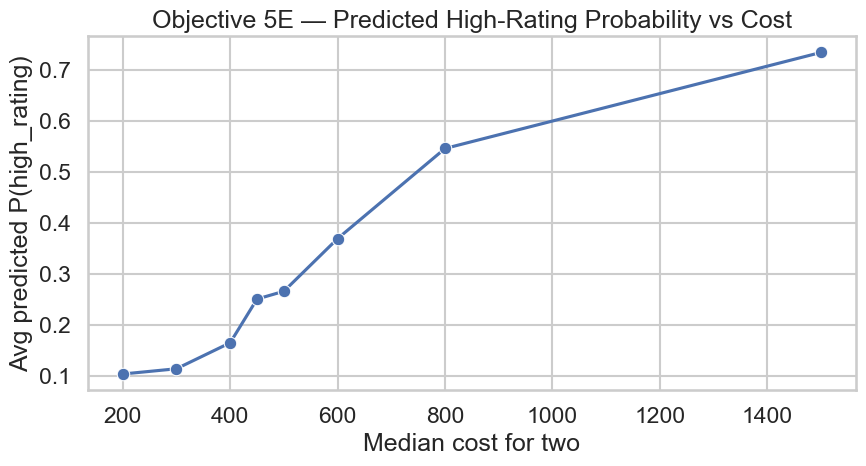

Insights:
- Top feature bar chart answers what matters most.
- Grouped importances answer whether location, cuisine, or operations dominate.
- ROC curve shows if the model is actually useful.
- Cost curve shows whether there is a price sweet spot.


In [44]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve

sns.set_theme(style="whitegrid", context="talk")

# ---------------- Cleaning ----------------
data = data.copy()
data["rating_num"] = pd.to_numeric(data["rating"], errors="coerce")
data["votes_num"] = pd.to_numeric(data["votes"], errors="coerce")
data["cost_for_two"] = pd.to_numeric(data["approx_cost(for two people)"], errors="coerce")
data["location_norm"] = data["location"].astype(str).str.strip().str.lower()
data["cuisine_list"] = data["cuisines"].apply(lambda xs: [str(x).strip().lower() for x in xs])

yn = {"Yes": 1, "No": 0, "yes": 1, "no": 0}
data["online_delivery_flag"] = data["online_delivery"].map(yn).astype(int)
data["book_table_flag"] = data["book_table"].map(yn).astype(int)

data = data.dropna(subset=["rating_num", "votes_num", "cost_for_two"])

# ---------------- Target ----------------
threshold = 4.2
data["high_rating"] = (data["rating_num"] >= threshold).astype(int)

# 5A: Class balance
class_balance = data["high_rating"].value_counts(normalize=True).sort_index() * 100
plt.figure(figsize=(6, 4))
ax = sns.barplot(
    x=["Not High Rated", "High Rated"],
    y=class_balance.values,
    palette="coolwarm"
)
for i, v in enumerate(class_balance.values):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center")
plt.title("Objective 5A — Class Balance for High-Rating Target")
plt.ylabel("% of restaurants")
plt.xlabel("")
plt.tight_layout()
plt.show()

# ---------------- Encoding ----------------
mlb = MultiLabelBinarizer()
cuisine_ohe = mlb.fit_transform(data["cuisine_list"])
cuisine_ohe = pd.DataFrame(
    cuisine_ohe,
    columns=[f"cuisine__{c}" for c in mlb.classes_],
    index=data.index
)

loc_ohe = pd.get_dummies(data["location_norm"], prefix="loc")

X_num = data[["cost_for_two", "votes_num", "online_delivery_flag", "book_table_flag"]].copy()
X = pd.concat([X_num, loc_ohe, cuisine_ohe], axis=1)
y = data["high_rating"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

clf = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample",
    min_samples_leaf=3
)
clf.fit(X_train, y_train)

proba = clf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, proba)
print("Objective 5: ROC AUC =", round(auc, 4))

imp = pd.DataFrame({
    "feature": X.columns,
    "importance": clf.feature_importances_
}).sort_values("importance", ascending=False)

# 5B: Top 20 feature importances
top_imp = imp.head(20).sort_values("importance", ascending=True)

plt.figure(figsize=(10, 8))
ax = sns.barplot(
    data=top_imp,
    x="importance",
    y="feature",
    palette="mako"
)
plt.title("Objective 5B — Top 20 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("")
plt.tight_layout()
plt.show()

# 5C: Grouped importances
def group_feature(f):
    if f in ["cost_for_two", "votes_num", "online_delivery_flag", "book_table_flag"]:
        return "Core numeric/ops"
    if f.startswith("loc_"):
        return "Location"
    if f.startswith("cuisine__"):
        return "Cuisine"
    return "Other"

imp["group"] = imp["feature"].apply(group_feature)
group_imp = (
    imp.groupby("group", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
)

plt.figure(figsize=(7, 4))
ax = sns.barplot(data=group_imp, x="importance", y="group", palette="viridis")
for i, row in group_imp.reset_index(drop=True).iterrows():
    ax.text(row["importance"] + 0.005, i, f'{row["importance"]:.3f}', va="center")
plt.title("Objective 5C — Total Importance by Feature Group")
plt.xlabel("Total importance")
plt.ylabel("")
plt.tight_layout()
plt.show()

# 5D: ROC curve
fpr, tpr, _ = roc_curve(y_test, proba)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {auc:.3f})", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.title("Objective 5D — ROC Curve")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.legend()
plt.tight_layout()
plt.show()

# 5E: Predicted probability vs cost
tmp = data.copy()
tmp["pred_proba"] = clf.predict_proba(X)[:, 1]
tmp = tmp[tmp["cost_for_two"] <= tmp["cost_for_two"].quantile(0.99)].copy()
tmp["cost_bin"] = pd.qcut(tmp["cost_for_two"], q=8, duplicates="drop")

cost_curve = (
    tmp.groupby("cost_bin", as_index=False)
    .agg(
        median_cost=("cost_for_two", "median"),
        mean_pred=("pred_proba", "mean"),
        n=("pred_proba", "size")
    )
    .sort_values("median_cost")
)

plt.figure(figsize=(9, 5))
sns.lineplot(data=cost_curve, x="median_cost", y="mean_pred", marker="o")
plt.title("Objective 5E — Predicted High-Rating Probability vs Cost")
plt.xlabel("Median cost for two")
plt.ylabel("Avg predicted P(high_rating)")
plt.tight_layout()
plt.show()

print("Insights:")
print("- Top feature bar chart answers what matters most.")
print("- Grouped importances answer whether location, cuisine, or operations dominate.")
print("- ROC curve shows if the model is actually useful.")
print("- Cost curve shows whether there is a price sweet spot.")


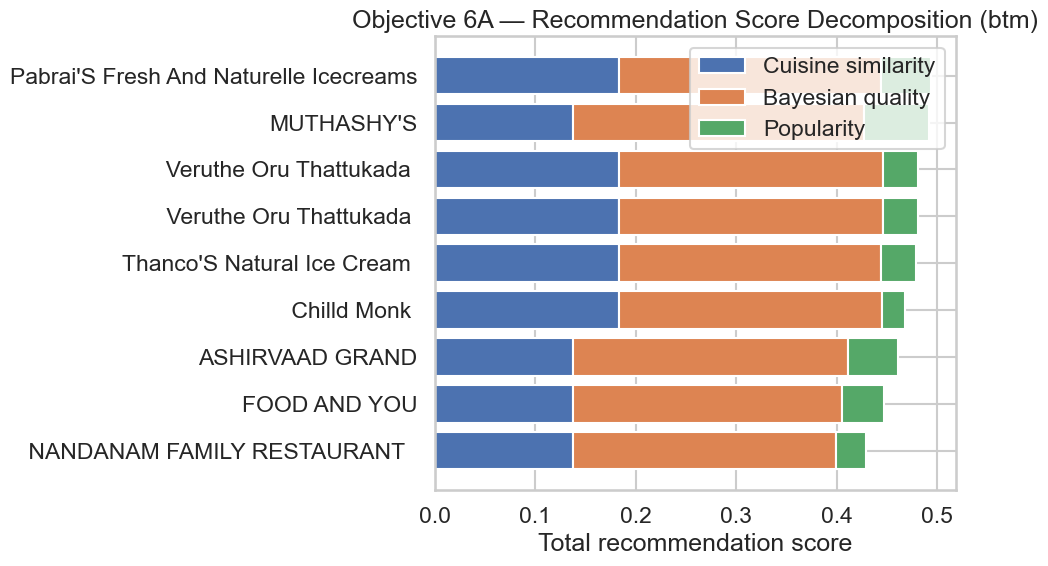

C:\Users\Monish Tarun\AppData\Local\Temp\ipykernel_11472\2741213103.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sim_long, x="Profile", y="Cuisine Similarity", palette="Set2")


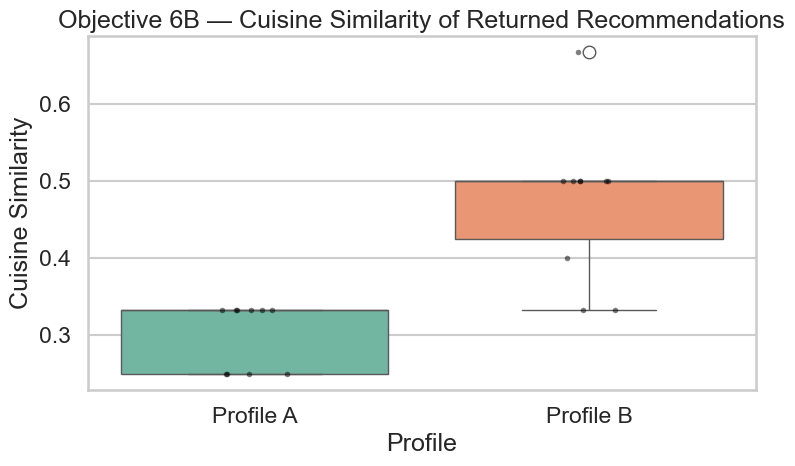

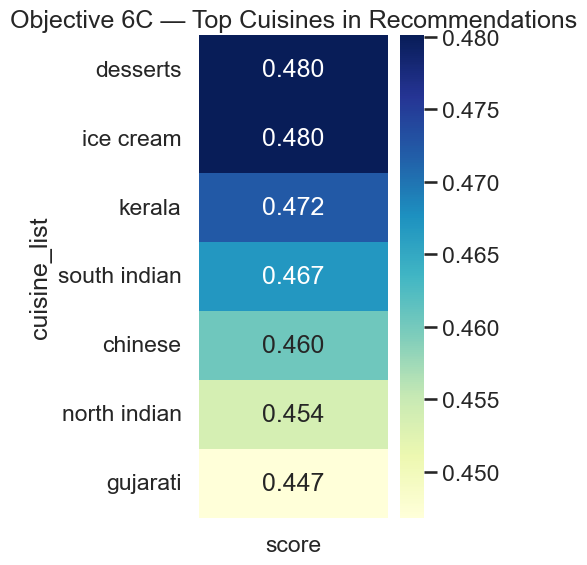

C:\Users\Monish Tarun\AppData\Local\Temp\ipykernel_11472\2741213103.py:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


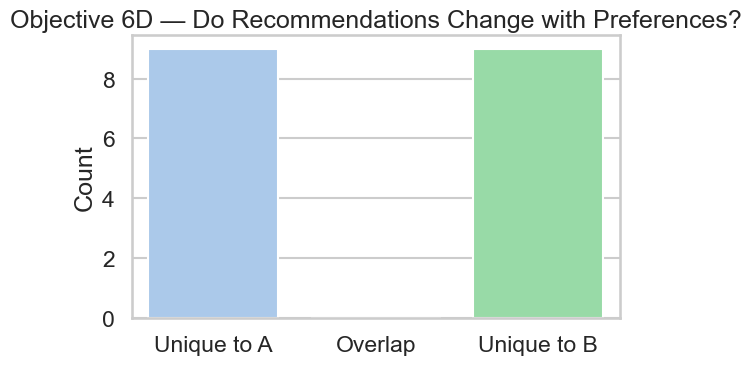

Insight:
Top-k overlap between profiles: 0
Low overlap means the recommender is preference-sensitive, not a generic filter.


In [45]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="talk")

# ---------------- Cleaning ----------------
data = data.copy()
data["rating_num"] = pd.to_numeric(data["rating"], errors="coerce")
data["votes_num"] = pd.to_numeric(data["votes"], errors="coerce")
data["cost_for_two"] = pd.to_numeric(data["approx_cost(for two people)"], errors="coerce")
data["location_norm"] = data["location"].astype(str).str.strip().str.lower()
data["cuisine_list"] = data["cuisines"].apply(lambda xs: [str(x).strip().lower() for x in xs])

data = data.dropna(subset=["rating_num", "votes_num", "cost_for_two"])

global_mean = data["rating_num"].mean()
m = data["votes_num"].quantile(0.60)

def bayes_rating(r, v, C=global_mean, m=m):
    return (v / (v + m)) * r + (m / (v + m)) * C

data["bayes_rating"] = bayes_rating(data["rating_num"], data["votes_num"])

def jaccard(a, b):
    a, b = set(a), set(b)
    if not a and not b:
        return 0.0
    return len(a & b) / len(a | b)

def recommend(location, budget, preferred_cuisines, k=10, budget_tol=0.25, min_votes=0):
    loc = str(location).strip().lower()
    pref = [str(c).strip().lower() for c in preferred_cuisines]

    cand = data[data["location_norm"] == loc].copy()
    cand = cand[cand["votes_num"] >= min_votes]

    low, high = budget * (1 - budget_tol), budget * (1 + budget_tol)
    cand = cand[(cand["cost_for_two"] >= low) & (cand["cost_for_two"] <= high)]
    if cand.empty:
        return cand

    cand["cuisine_sim"] = cand["cuisine_list"].apply(lambda xs: jaccard(xs, pref))

    max_votes = max(data["votes_num"].max(), 1.0)
    cand["sim_component"] = 0.55 * cand["cuisine_sim"]
    cand["quality_component"] = 0.35 * (cand["bayes_rating"] / 5.0)
    cand["pop_component"] = 0.10 * (np.log1p(cand["votes_num"]) / np.log1p(max_votes))
    cand["score"] = cand["sim_component"] + cand["quality_component"] + cand["pop_component"]

    return cand.sort_values("score", ascending=False).head(k)

loc0 = data["location_norm"].value_counts().index[0]
budget0 = float(data["cost_for_two"].median())

rec_a = recommend(loc0, budget0, ["south indian", "desserts"], k=10)
rec_b = recommend(loc0, budget0, ["chinese", "biryani"], k=10)

# 6A: Score decomposition for profile A
if len(rec_a) > 0:
    r = rec_a.copy().sort_values("score", ascending=True)
    plt.figure(figsize=(10, 6))
    plt.barh(r["restaurant_name"], r["sim_component"], label="Cuisine similarity")
    plt.barh(r["restaurant_name"], r["quality_component"], left=r["sim_component"], label="Bayesian quality")
    plt.barh(r["restaurant_name"], r["pop_component"],
             left=r["sim_component"] + r["quality_component"], label="Popularity")
    plt.title(f"Objective 6A — Recommendation Score Decomposition ({loc0})")
    plt.xlabel("Total recommendation score")
    plt.legend()
    plt.tight_layout()
    plt.show()

# 6B: Top-k cuisine similarity comparison
if len(rec_a) > 0 and len(rec_b) > 0:
    sim_df = pd.DataFrame({
        "Profile A": rec_a["cuisine_sim"].values,
        "Profile B": rec_b["cuisine_sim"].values
    })
    sim_long = sim_df.melt(var_name="Profile", value_name="Cuisine Similarity")

    plt.figure(figsize=(8, 5))
    sns.boxplot(data=sim_long, x="Profile", y="Cuisine Similarity", palette="Set2")
    sns.stripplot(data=sim_long, x="Profile", y="Cuisine Similarity",
                  color="black", alpha=0.5, size=4)
    plt.title("Objective 6B — Cuisine Similarity of Returned Recommendations")
    plt.tight_layout()
    plt.show()

# 6C: Heatmap of top recommendation cuisines
if len(rec_a) > 0:
    exploded = rec_a[["restaurant_name", "cuisine_list", "score"]].explode("cuisine_list")
    cuisine_score = (
        exploded.groupby("cuisine_list", as_index=False)["score"]
        .mean()
        .sort_values("score", ascending=False)
        .head(10)
    )
    heat_df = cuisine_score.set_index("cuisine_list")[["score"]]

    plt.figure(figsize=(5, 6))
    sns.heatmap(heat_df, annot=True, cmap="YlGnBu", fmt=".3f")
    plt.title("Objective 6C — Top Cuisines in Recommendations")
    plt.tight_layout()
    plt.show()

# 6D: Intelligence check
if len(rec_a) > 0 and len(rec_b) > 0:
    overlap = set(rec_a["restaurant_name"]) & set(rec_b["restaurant_name"])
    overlap_count = len(overlap)

    plt.figure(figsize=(6, 4))
    sns.barplot(
        x=["Unique to A", "Overlap", "Unique to B"],
        y=[len(set(rec_a["restaurant_name"]) - overlap), overlap_count, len(set(rec_b["restaurant_name"]) - overlap)],
        palette="pastel"
    )
    plt.title("Objective 6D — Do Recommendations Change with Preferences?")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    print("Insight:")
    print("Top-k overlap between profiles:", overlap_count)
    print("Low overlap means the recommender is preference-sensitive, not a generic filter.")
